# Model-based T1 reconstruction (BART `moba -L`) — synthetic phantom, V2: first stable version

Model-based alternative to the joint-LLR reconstruction (`RECON_COMPARISON.md`, method 2):
`moba` estimates the parameter maps of the IR signal model — and the coil sensitivities —
**directly from the undersampled k-space of all four TIs at once** (Wang et al., MRM
2018;79:730, doi:10.1002/mrm.26726), with the iteratively regularised Gauss-Newton method
(IRGNM); each Newton step's linear subproblem is solved by FISTA with a joint l1-wavelet
penalty on the parameter maps.

**Data: synthetic phantom only** (`synth/phantom.py`, static head); no subject data are used.

**What V2 adds to V1** (`Recon_MOBA_V1.ipynb`, which stays as the record of the first build).
V1 diverged in many readout slices. Section 7 diagnoses why on single readout slices and
arrives at a configuration that converges in every slice; the rest of the pipeline is V1's,
now executed end to end (V1's sections 10-15 were never run).

| | V1 | V2 | why (section 7) |
|---|---|---|---|
| data scaling | `--normalize_scaling --scale_data 5000 --scale_psf 1000`: every slice's data norm set to 5000 | **fixed per plane**: `--scale_data K/σ` (σ = k-space noise SD), `--scale_psf` = moba's own PSF normalisation | per-slice normalisation gives noisy (peripheral) slices the weakest regularisation relative to their noise |
| coil smoothness | `--sobolev_a 880` (default) | **`--sobolev_a 220`** | the default coil model cannot represent the coils (10-13 % error); the error ends up in the maps |
| α_min (`-j`) | 0.01 | **0.3** | below ~0.1 the late, weakly regularised Newton steps diverge in some slices |
| Newton steps (`-i`) | 8 | **10** | two more steps at α ≈ α_min (converged schedule) |

| step | what | section |
|---|---|---|
| 0 | verify that the protocol's IR equation is exactly `moba -L`'s model; TI file units/dims | 3 |
| 1 | load and stack the 4 TIs per plane and echo group (`pipeline_utils.stack_tis`) | 4 |
| 2 | remove the per-TI global phase offsets (moba shares one complex image across TIs) | 5 |
| 3 | coil sensitivities: what `moba -L` can and cannot take | 6 |
| 4 | **stability diagnosis on single readout slices** (new) | 7 |
| 5 | `moba -L` per echo group → M_ss, M0', R1*, per-slice convergence check | 8-9 |
| 6 | T1 = 1/R1*, combine echo groups, evaluate vs truth | 10-11 |
| 7 | model-consistency checks: synthesised TI images, k-space residual, M0'/M_ss | 12-13 |
| 8 | coil-map QC, LLR reference for context, all planes | 14-16 |
| 9 | what a per-plane T1 output means for 3-plane super-resolution; report | 17-18 |

**Not tuned yet.** V2 is the first configuration that is *stable*; α_min, iterations,
regulariser and coil initialisation are tuned next, stage by stage with the researcher
(section 18 lists the plan).

## 1. Environment

In [1]:
import os
import sys
import re
import time
import json
import subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

os.environ.setdefault('BART_TOOLBOX_PATH', str(Path('~/bart').expanduser()))
REPO = Path.cwd()
sys.path.insert(0, str(REPO / 'synth'))
sys.path.insert(0, str(REPO / 'moba_dev'))
import pipeline_utils as pu                      # shared conventions (do not re-implement)
from pipeline_utils import bart
from phantom import load_scans
import diag_slice as ds                          # single-readout-slice moba harness (section 7)

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
BART_BIN = os.path.join(os.environ['BART_TOOLBOX_PATH'], 'bart')
print(subprocess.run([BART_BIN, 'version'], capture_output=True, text=True).stdout.strip(),
      '|', os.environ['BART_TOOLBOX_PATH'], '|', os.cpu_count(), 'CPUs')

v1.0.00 | /root/bart | 4 CPUs


## 2. Configuration

The phantom lives outside the repo (`python synth/phantom.py ~/work/phantom`); derived
data are cached in `PROC_DIR` (also outside the repo). Delete a cache file to force a re-run.

`moba` options, V2 (**stable, not tuned**; section 7 derives each one):

| option | value | meaning |
|---|---|---|
| `-L` | | 3-parameter IR model S = M_ss − (M_ss + M0') e^(−TI·R1*) |
| `-l1` | | joint l1-wavelet penalty on the 3 parameter maps (moba default) |
| `-i` | 10 | IRGNM (Newton) steps |
| `-C` | 100 | max. FISTA iterations per Newton step (moba caps step n at min(C, 10·2^n)) |
| `-j` | 0.3 | minimum regularisation α_min; α_n = α_min + (1 − α_min)/2^n (`-R 2` default) |
| `--sobolev_a` | 220 | coil smoothness weight (moba default 880); `b` stays 32 |
| `--scale_data` | K/σ, K = 4.545 | data scale referenced to the k-space noise SD σ (= 45 in the coronal plane) |
| `--scale_psf` | 1000/‖PSF‖ | moba's own PSF normalisation (constant within a plane) |
| init | M_ss = M0' = 1, R1* = 1 s⁻¹ | moba default |
| R1* ≥ 0 | | moba default (last map constrained) |

`V1_OPTS` is kept for the section-7 comparison.

In [2]:
PHANTOM_DIR = Path(os.environ.get('QT1_PHANTOM_DIR', '~/work/phantom')).expanduser()
PROC_DIR    = PHANTOM_DIR / 'moba'            # derived data, outside the repo
PROC_DIR.mkdir(exist_ok=True)

PLANE          = 'COR'                        # end-to-end validation plane
RUN_ALL_PLANES = os.environ.get('MOBA_ALL_PLANES', '0') == '1'   # section 16 (AX, SAG: ~45 min each on 4 cores)

# ---- moba, V2 (stable, untuned) -------------------------------------------------
MOBA_NEWTON     = 10
MOBA_INNER      = 100
MOBA_REG        = '-l1'
MOBA_ALPHA_MIN  = 0.3
MOBA_SOBOLEV_A  = 220
NOISE_REF_SCALE = 4.545       # --scale_data = NOISE_REF_SCALE / sigma_k  (45 for the coronal plane)
MOBA_OPTS = f'-L {MOBA_REG} -i {MOBA_NEWTON} -C {MOBA_INNER} -j {MOBA_ALPHA_MIN} --sobolev_a {MOBA_SOBOLEV_A}'
MOBA_JOBS = os.cpu_count()    # readout slices reconstructed in parallel, 1 thread each
V1_OPTS = '-L -l1 -i 8 -C 100 -j 0.01 --normalize_scaling --scale_data 5000 --scale_psf 1000'

# ---- per-TI global phase (section 5) -----------------------------------------
PHASE_CORR  = True       # demodulate the per-TI global phase before moba
PHASE_TAPER = 0.15       # Gaussian k-space taper (SD as a fraction of the matrix) for the estimate

# ---- echo groups (section 10) -----------------------------------------------
ECHO_COMBINE = 'mean_R1'   # average R1* of the two echo groups, T1 = 1 / mean

MOBA_TAG = (f'v2_L{MOBA_REG}_i{MOBA_NEWTON}_C{MOBA_INNER}_j{MOBA_ALPHA_MIN}_a{MOBA_SOBOLEV_A}'
            f'_k{NOISE_REF_SCALE}_ph{int(PHASE_CORR)}')
scans = load_scans(PHANTOM_DIR)
PLANES = tuple(scans)
print('phantom:', PHANTOM_DIR, '| planes', PLANES, '| cache', PROC_DIR)
print('moba', MOBA_OPTS, '+ per-plane --scale_data / --scale_psf')

phantom: /root/work/phantom | planes ('AX', 'COR', 'SAG') | cache /root/work/phantom/moba
moba -L -l1 -i 10 -C 100 -j 0.3 --sobolev_a 220 + per-plane --scale_data / --scale_psf


## 3. Does `moba -L` fit our signal model? (numerical verification)

The protocol's IR-FSE signal (full inversion, readout, recovery of length c = TR − TI):

$$S(TI) = M_0\left(1 - 2e^{-TI/T_1} + e^{-TR/T_1}\right),\qquad TR = TI + c$$

`moba -L` fits (BART `src/moba/T1fun.c`, "Mss − (Mss + M0)·exp(−t·R1s)"):

$$S(TI) = M_{ss} - (M_{ss} + M_0')\,e^{-TI\,R_1^*}$$

Substituting TR = TI + c: S = M0 − M0 (2 − e^(−c/T1)) e^(−TI/T1), so the two are identical with

$$M_{ss} = M_0,\qquad M_0' = M_0\left(1 - e^{-c/T_1}\right),\qquad R_1^* = 1/T_1$$

— **provided c is the same at every TI**. There is no Look-Locker flip-angle correction here
(no continuous FLASH readout during recovery), so T1 = 1/R1* directly; BART's `looklocker`
tool (T1 = M0'/(M_ss·R1*)) must **not** be applied.

Two consequences:

* moba does not know c and does not impose M0' = M0 (1 − e^(−c/T1)); M0' is a free (complex)
  parameter. moba therefore fits 3 parameters (plus phases) to 4 TIs, where the PSIR grid fit
  (`fit_t1_grid`, TR known) fits 2. Less constrained → more noise, and sensitive to model
  errors for long T1 (below).
* The protocol does **not** have one c: TI31 has TR = 1.225 s (c = 1.19425 s), the others
  c = 1.200 s. The second cell quantifies the resulting error by fitting the moba model
  (3 free parameters, least squares, noise-free) to the exact protocol signal.

In [3]:
TI_s = {p: np.array([s['info']['TI_s'] for s in scans[p]]) for p in PLANES}
TR_s = {p: np.array([s['info']['TR_s'] for s in scans[p]]) for p in PLANES}
for p in PLANES[1:]:
    assert np.allclose(TI_s[p], TI_s[PLANES[0]]) and np.allclose(TR_s[p], TR_s[PLANES[0]])
TI, TR = TI_s[PLANE], TR_s[PLANE]
print('TI (s):', TI, '\nTR (s):', TR, '\nc = TR - TI (s):', TR - TI)


def ir_model(M0, T1, ti, tr):
    return M0 * (1 - 2 * np.exp(-ti / T1) + np.exp(-tr / T1))


def ll_model(Mss, M0p, R1, ti):
    return Mss - (Mss + M0p) * np.exp(-ti * R1)


T1_grid = np.logspace(np.log10(0.1), np.log10(4.0), 300)          # s
C_NOM = 1.2
err = max(np.abs(ir_model(1.0, t, TI, TI + C_NOM)
                 - ll_model(1.0, 1 - np.exp(-C_NOM / t), 1 / t, TI)).max() for t in T1_grid)
print(f'\n(a) exact mapping, c = {C_NOM} s at every TI: max |S_IR - S_moba| / M0 = {err:.1e} '
      f'over T1 = 0.1-4 s')

TI (s): [0.03075 0.15    0.4     0.8    ] 
TR (s): [1.225 1.35  1.6   2.   ] 
c = TR - TI (s): [1.19425 1.2     1.2     1.2    ]

(a) exact mapping, c = 1.2 s at every TI: max |S_IR - S_moba| / M0 = 4.4e-16 over T1 = 0.1-4 s


(b) T1 bias from c(TI31) = 1.19425 s vs 1.200 s (noise-free, moba model fitted to the exact protocol signal)
 T1 true (ms)  T1 moba (ms)   bias %  M_ss/M0 max resid/M0
        183.0         183.0    0.003   1.0000      4.9e-06
        258.6         258.6    0.021   1.0001      3.3e-05
        307.3         307.4    0.043   1.0002      6.7e-05
        339.2         339.4    0.062   1.0003      9.7e-05
        497.2         498.3    0.214   1.0015      2.6e-04
       1004.5        1016.6    1.199   1.0120      5.3e-04
       2004.5        2094.2    4.473   1.0498      5.2e-04
       3492.4        3885.3   11.252   1.1247      4.0e-04

signal difference at TI31: 2.0e-04 M0 (T1 260 ms), 1.2e-03 M0 (T1 3.5 s)


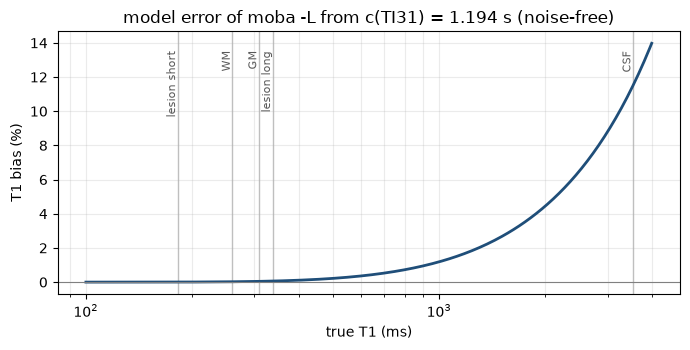

In [4]:
# (b) the real protocol (c = 1.19425 s at TI31): fit moba's 3 free parameters to the exact signal
fit = []
for t in T1_grid:
    s = ir_model(1.0, t, TI, TR)
    r = least_squares(lambda q: ll_model(q[0], q[1], q[2], TI) - s,
                      [1.0, 1 - np.exp(-C_NOM / t), 1 / t], xtol=1e-15, ftol=1e-15, gtol=1e-15)
    fit.append((1 / r.x[2], r.x[0], r.x[1], np.abs(r.fun).max()))
fit = np.array(fit)
bias_model = 100 * (fit[:, 0] - T1_grid) / T1_grid

print('(b) T1 bias from c(TI31) = 1.19425 s vs 1.200 s (noise-free, moba model fitted to the '
      'exact protocol signal)')
print(f"{'T1 true (ms)':>13s} {'T1 moba (ms)':>13s} {'bias %':>8s} {'M_ss/M0':>8s} {'max resid/M0':>12s}")
for t in (0.182, 0.26, 0.309, 0.338, 0.5, 1.0, 2.0, 3.5):
    i = np.argmin(np.abs(T1_grid - t))
    print(f'{1000 * T1_grid[i]:13.1f} {1000 * fit[i, 0]:13.1f} {bias_model[i]:8.3f} '
          f'{fit[i, 1]:8.4f} {fit[i, 3]:12.1e}')
d31 = [ir_model(1, t, TI[0], TR[0]) - ir_model(1, t, TI[0], TI[0] + C_NOM) for t in (0.26, 3.5)]
print(f'\nsignal difference at TI31: {d31[0]:.1e} M0 (T1 260 ms), {d31[1]:.1e} M0 (T1 3.5 s)')

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogx(1000 * T1_grid, bias_model, color='#1f4e79', lw=2)
for t, n in ((182, 'lesion short'), (260, 'WM'), (309, 'GM'), (338, 'lesion long'), (3543, 'CSF')):
    ax.axvline(t, color='0.75', lw=1, zorder=0)
    ax.text(t, ax.get_ylim()[1] * 0.92, n, rotation=90, ha='right', va='top', fontsize=8, color='0.35')
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xlabel('true T1 (ms)'); ax.set_ylabel('T1 bias (%)')
ax.set_title('model error of moba -L from c(TI31) = 1.194 s (noise-free)')
ax.grid(alpha=0.25, which='both'); plt.tight_layout(); plt.show()

**Result.** (a) With a single c the mapping is exact to machine precision. (b) The
6 ms shorter recovery at TI31 changes the signal by ~2·10⁻⁴ M0 in WM, which moves the
fitted T1 by **< 0.1 % for all brain tissue and lesions (180-340 ms)** — negligible
against partial volume and noise. It grows with T1 (≈ 1 % at 1 s) and is **≈ +11 % for
CSF** (3.5 s): with TIs ≤ 0.8 s a CSF curve is still in its early, almost linear part, the
3-parameter fit is ill-conditioned there, and a tiny model error moves M_ss and R1*
together. CSF T1 from moba is therefore biased by the model alone (in addition to the
partial-volume shift in `ideal`) and not reliable at this TI range.

### TI file: units and dimensions

`moba` multiplies the TI array directly by R1* (`T1fun.c`: exp(−t·R1s), with parameter
scaling 1), so **the units of R1* are the inverse of the TI file's units**. BART's own
`moba` tests and Wang's scripts use seconds; we do the same, so R1* is in s⁻¹ and
T1 (ms) = 1000 / R1*. The file must be a complex array of shape
**(1, 1, 1, 1, 1, n_TI)** — TIs along dim 5 (TE_DIM), matching the k-space
(`moba.c` asserts `TI_dims[TE_DIM] == ksp_dims[TE_DIM]`). The initial R1* = 1 s⁻¹
(T1 = 1 s) is within a factor 4 of brain T1 and 3.5 of CSF.

In [5]:
def ti_file(scans_plane):
    return np.array([s['info']['TI_s'] for s in scans_plane], np.complex64).reshape(1, 1, 1, 1, 1, -1)


print('TI file', ti_file(scans[PLANE]).shape, np.real(ti_file(scans[PLANE])).ravel(), '(s)')

TI file (1, 1, 1, 1, 1, 4) [0.03075 0.15    0.4     0.8    ] (s)


## 4. Stack the TIs per plane and echo group

`pipeline_utils.stack_tis` puts the 4 TIs along dim 5, the dimension `moba` treats as the
signal-model dimension (TI/TE). The trajectory is passed as a wrapper keyword argument
(`t=T`). The coronal and sagittal TIs have equal PE counts; axial TI31 has 992 vs 800, so
the other axial TIs are zero-padded and `stack_tis` returns a zero-weight pattern `P`.

**`moba -p` is not a sampling weight.** In `moba`, `-p <PSF>` means *pre-gridded Cartesian
k-space plus its point-spread function* (the `-p psf.ra k_space.ra` usage in BART's tests);
it is not the per-sample weight file of `pics -p`, and passing `P` there would be wrong.
It is also unnecessary: with `-t`, `moba` builds its PSF from the data itself —
`estimate_pattern()` (`src/misc/mri2.c`) sets the weight of every sample to 1 where the
coil RSS is non-zero and 0 elsewhere — so the zero-padded samples get zero weight and add
nothing to the gridded data either. The cell below confirms that the padded samples are
exactly zero in every coil (so `estimate_pattern` removes exactly them).

In [6]:
for p in PLANES:
    T, D, P = pu.stack_tis(scans[p], 0)
    zero = np.all(D == 0, axis=3)[0, :, :, 0, :]                 # (read, pe, TI): all coils zero
    msg = 'no padding'
    if P is not None:
        pad = np.real(P[0, :, :, 0, 0, :]) == 0                  # (read, pe, TI)
        msg = (f'padded samples per TI {pad.sum(axis=(0, 1))}; all-coil-zero samples '
               f'{zero.sum(axis=(0, 1))}; identical: {np.array_equal(pad, zero)}')
    print(f'{p:4s} traj{T.shape} data{D.shape}  {msg}')

AX   traj(3, 100, 992, 1, 1, 4) data(1, 100, 992, 8, 1, 4)  padded samples per TI [    0 19200 19200 19200]; all-coil-zero samples [    0 19200 19200 19200]; identical: True
COR  traj(3, 112, 736, 1, 1, 4) data(1, 112, 736, 8, 1, 4)  no padding


SAG  traj(3, 122, 672, 1, 1, 4) data(1, 122, 672, 8, 1, 4)  no padding


## 5. Per-TI global phase

`moba -L` has **one complex M_ss and one complex M0' per voxel** shared by all TIs (R1* is
real). A smooth phase common to all TIs (background, coils, the extra phase of echo group 1)
is absorbed by the complex maps and the jointly estimated coils. A **global phase that
differs between TI scans** (measured 4-9° on real data; SD 5° in the phantom) is not in the
model and would be fitted as a spurious curve shape.

**First approach (implemented): estimate and demodulate in k-space.** A constant phase
multiplies k-space linearly, so each TI's data are multiplied by e^(−iΔφ_j) before `moba`.
Δφ_j (relative to the reference TI, TI800) comes from per-coil low-resolution gridding
images g_{j,c} (adjoint NUFFT with a Gaussian k-space taper), no coil maps needed:

$$\Delta\varphi_j = \tfrac12\,\arg\sum_{\mathbf r}\Big(\sum_c g_{j,c}(\mathbf r)\,g^*_{\mathrm{ref},c}(\mathbf r)\Big)^2$$

The coil product cancels coil and background phase and leaves s_j s_ref e^(iΔφ_j), which is
real up to Δφ_j but has either sign (inverted tissue); squaring removes the sign
(doubled-angle estimator, valid for |Δφ| < 90°), the sum weights by signal energy. Both
echo groups are estimated independently (they should agree). The phantom stores the true
offsets (`ti_phase_rad`), used here **for validation only**.

**Alternatives** (not implemented):
1. Estimate Δφ from a per-TI SENSE/LLR reconstruction (coil maps needed; same estimator).
2. Iterate: run moba, synthesise the TI images, re-estimate Δφ from data vs model, re-run.
3. Joint estimation inside the model: a per-TI phase parameter (not available in `moba -L`;
   would need a custom nlop or `--bloch`-style model).
4. Do nothing: moba's complex M_ss and M0' can represent a two-level phase along TI, which
   absorbs part of a small offset, at the cost of a biased curve shape.
5. Use real-valued (PSIR) constraints: not possible in `moba -L` (M_ss, M0' complex).

In [7]:
def ti_phase_offsets(T, D, matrix, width=PHASE_TAPER, ref=pu.REF_TI_IDX):
    # Global phase of each TI relative to `ref` (radians), doubled-angle estimator on
    # per-coil tapered gridding images (see markdown above).
    tr = np.real(T)
    w = np.exp(-0.5 * sum((tr[a] / (width * matrix[a])) ** 2 for a in range(3)))[None]
    g = pu.checked(bart(1, 'nufft -a -d {}:{}:{}'.format(*matrix), T, (D * w).astype(np.complex64)))
    prod = np.sum(g * np.conj(g[..., ref])[..., None], axis=3)           # (X, Y, Z, TI)
    return 0.5 * np.angle(np.sum(prod.astype(np.complex128) ** 2, axis=(0, 1, 2)))


def phase_offsets_cached(p, e):
    f = PROC_DIR / f'dphi_{p}_e{e}_w{PHASE_TAPER}.npy'
    if f.exists():
        return np.load(f)
    T, D, _ = pu.stack_tis(scans[p], e)
    d = ti_phase_offsets(T, D, scans[p][pu.REF_TI_IDX]['info']['matrix'])
    np.save(f, d)
    return d


print(f"{'plane':5s} {'echo':>4s}  " + '  '.join(f'TI{1000 * t:.0f}'.rjust(15) for t in TI)
      + '     (estimated / true, degrees)')
for p in PLANES:
    true = np.array([s['info']['ti_phase_rad'] for s in scans[p]])
    true = np.degrees(true - true[pu.REF_TI_IDX])
    for e in (0, 1):
        est = np.degrees(phase_offsets_cached(p, e))
        print(f'{p:5s} {e:4d}  ' + '  '.join(f'{a:6.2f} / {b:6.2f}' for a, b in zip(est, true)))

plane echo             TI31            TI150            TI400            TI800     (estimated / true, degrees)
AX       0   -8.38 /  -8.51   -2.17 /  -1.27    1.34 /   1.18    0.00 /   0.00
AX       1   -8.41 /  -8.51   -2.20 /  -1.27    1.31 /   1.18    0.00 /   0.00
COR      0    9.76 /   9.75    8.52 /   9.64   11.37 /  11.33    0.00 /   0.00
COR      1    9.73 /   9.75    8.45 /   9.64   11.42 /  11.33    0.00 /   0.00
SAG      0   10.30 /  10.36    5.26 /   6.04    3.78 /   3.52    0.00 /   0.00
SAG      1   10.34 /  10.36    5.26 /   6.04    3.77 /   3.52    0.00 /   0.00


The offsets are recovered to within ~0.3° at TI31 and TI400 and to 0.8-1.2° at TI150 in
every plane and both echo groups (true offsets up to 11°). The TI150 error is systematic (the same in both echo groups and
independent of the taper width, 0.15-5 tried while building this), so it is a property of
the estimator, not noise: at TI150 WM is close to its null and the image is dominated by
inverted GM/CSF, where signed signal of both polarities within the smooth phase field
breaks the "real up to Δφ" assumption slightly. A residual ~1° is well below the 5-10°
being corrected; alternative 2 above would remove it if it matters.

## 6. Coil sensitivities: what `moba -L` accepts

**`moba` does not accept external coil maps as the last argument.** In BART v1.0.00 the last
positional argument `<sensitivities>` is an *output* (`ARG_OUTFILE` in `src/moba.c`):
`moba` writes the coil maps it estimated. The only coil input is
`--other ksp-sens=<file>`, which is an **initial value in moba's internal k-space
representation** (coils are parameterised as Sobolev-weighted k-space, as in NLINV), not
image-space maps, and the coils are still updated. The switch that freezes the coils
(`--other no-sens-deriv`) is only honoured by the `-P`/`--bloch` models
(`src/moba/model_moba.c`), not by `-L` (`model_T1.c` chains the T1 model into a plain
`noir_create` operator).

So **the shared self-calibrated maps from `pu.shared_selfcal` cannot be passed to `moba -L`**.
What `moba -L` does instead is itself a self-calibration of the same kind:

* coils are unknowns of the same nonlinear problem (NLINV/ENLIVE-style joint estimation,
  Uecker et al. 2008), regularised by a Sobolev norm (smoothness; `a = 880, b = 32`);
* coils are **constant across TI** (`cnstcoil_flags = TE_FLAG` in `recon.c`), i.e. one set
  of coils shared by the four TIs — the same assumption as `ncalib --shared-col-dims 32`;
* but they are estimated jointly with the **parameter maps** instead of with four free TI
  images — the coil-image ambiguity is resolved by the signal model;
* **one map set only**: `moba` asserts `ksp_dims[MAPS_DIM] == 1`, and the image is
  M_ss/M0'/R1*, so there is no soft-SENSE equivalent. The 2-map-set maps have no place in
  `moba -L`; the closest counterpart is `shared_selfcal(..., nmaps=1)`, which section 13
  compares with moba's own maps (and with the true maps) — section 14 here.

On the real data a single ENLIVE map set produced a band artefact in the coronal plane
(`T1map_3plane_SR_V1.ipynb`, section 7). Whether moba's jointly estimated single map set
reproduces it can only be checked on real data; the phantom has no such inconsistency.
**New in V2 — the coil model and `ksp-sens`.** moba's coils are c = fftmod(IFFT(w ⊙ ĉ)) on
its 2× oversampled grid, with Sobolev weights w = (1 + a·|k|²)^(−b/2) (`noir/model.c`,
`noir_calc_weights`); `moba_dev/diag_slice.py: coils_from_ksp` reproduces moba's own output
from its exported k-space coils (`--other export-ksp-sens`) to 2·10⁻⁶, and `ksp_from_coils`
inverts it (band-limited where w > 10⁻³ max w) to build a `ksp-sens` initial value from any
image-space maps. Two findings (section 7d):

* with the default `a = 880` the coil model **cannot represent the phantom's coils** better
  than 10-13 % (relative error inside the head); `a = 220` brings this to 4-6 %. The part of
  the coils the model cannot represent ends up in the parameter maps. V2 uses `a = 220`.
* initialising moba with the **true** coils (oracle, via `ksp-sens`) helps much less than
  the smaller `a`, so the coil *model*, not the coil *initialisation*, was limiting.
  Initialising from `shared_selfcal(nmaps=1)` is therefore left to the tuning stage.

## 7. Stability diagnosis on single readout slices (new in V2)

V1 diverged: the residual rose again in the late, weakly regularised Newton steps, and R1*
collapsed towards 0 in some voxels, mostly in readout slices towards the head periphery.
Because the readout is fully sampled and Cartesian, every readout position is an
independent 2D problem (section 8), so the solver can be studied one slice at a time
(35-50 s per slice, single thread). `moba_dev/diag_slice.py` runs one slice exactly as the
full reconstruction does and reports:

* **raw-data residual** ‖y − A(c·ρ)‖/‖y‖: moba's coils × model images put back on the data
  scale and taken to k-space with the NUFFT, next to the **noise floor** √N·σ/‖y‖.
  moba's image × coil product equals the true image × 2·s_data/s_psf (the 2: the unitary FFT
  on moba's 2× oversampled grid; confirmed on a converged slice, where the residual then
  equals the noise floor to 3 digits). A converged, regularised fit sits at or somewhat below
  the noise floor (~5 real unknowns per voxel against ~11 real samples); **far above it
  means the solution is broken**.
* **collapsed voxels**: fraction of GM/WM/lesion voxels with T1 = 1/R1* > 1 s;
* median T1 per tissue vs the resolution-limited ideal on that slice.

The **screen** uses 13 readout slices, x = 8, 16, …, 104 (bottom of the head to its top;
x = 8 and 104 hold only scalp/skull). All results are cached in `PROC_DIR/diag/cache`
(keyed by plane, slice, echo and options); a fresh run of this section takes ~25 min on 4
cores.

In [8]:
XS = list(range(8, 112, 8))
FIXED = '--scale_data 45 --scale_psf 17.971312'      # coronal: noise-referenced data scale, moba's PSF scale
V2_SLICE = f'-L -l1 -C 100 -i 10 {FIXED} --sobolev_a 220 -j 0.3'     # = MOBA_OPTS + the coronal scaling
truth = dict(np.load(PHANTOM_DIR / f'truth_{PLANE}.npz'))


def screen(opts, e=0, xs=XS, tag=''):
    return ds.run_many([dict(plane=PLANE, x=x, opts=opts, e=e, tag=f'{tag} x={x}') for x in xs], verbose=False)


def bias(r, name):
    v = r['rows'].get(name)
    return 100 * (v['med'] - v['ideal']) / v['ideal'] if v else np.nan


def plot_screens(runs, title):
    fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
    for (lab, rr), col in zip(runs.items(), ('#c0504d', '#1f4e79', '#7fa7cf', '#9bbb59', '#8064a2')):
        x = [r['x'] for r in rr]
        ax[0].semilogy(x, [r['final_res'] / r['noise_floor'] for r in rr], 'o-', color=col, label=lab)
        ax[1].plot(x, [100 * r['rows']['collapsed_frac'] for r in rr], 'o-', color=col, label=lab)
        ax[2].plot(x, [bias(r, 'WM') for r in rr], 'o-', color=col, label=f'{lab}: WM')
        ax[2].plot(x, [bias(r, 'GM') for r in rr], 's--', color=col, alpha=0.6, label=f'{lab}: GM')
    ax[0].axhline(1, color='0.4', lw=0.8); ax[0].set_ylabel('raw residual / noise floor')
    ax[1].set_ylabel('collapsed brain voxels (%)'); ax[2].set_ylabel('median T1 vs ideal (%)')
    ax[2].set_ylim(-40, 40); ax[2].axhline(0, color='0.4', lw=0.8)
    for a in ax:
        a.set_xlabel('readout slice x'); a.grid(alpha=0.25)
    ax[0].legend(fontsize=8); ax[2].legend(fontsize=7, ncol=2)
    plt.suptitle(title); plt.tight_layout(); plt.show()


def table(rr):
    print(f"{'':24s} {'x':>4s} {'res/noise':>9s} {'coll%':>6s} {'WM med/ideal':>13s} {'GM med/ideal':>13s} {'s_data':>7s}")
    for r in rr:
        w, g = r['rows'].get('WM'), r['rows'].get('GM')
        f = lambda v: f"{v['med']:6.0f}/{v['ideal']:<6.0f}" if v else ' ' * 13
        print(f"{r['tag']:24s} {r['x']:4d} {r['final_res'] / r['noise_floor']:9.2f} "
              f"{100 * r['rows']['collapsed_frac']:6.1f} {f(w)} {f(g)} {r['scale_data']:7.1f}")

### 7a. V1 reproduces the divergence

V1's options on the 13-slice screen (echo group 0):

                            x res/noise  coll%  WM med/ideal  GM med/ideal  s_data
V1 x=8                      8      0.92    nan                               274.3
V1 x=16                    16      4.78    7.8                  108/326      181.4
V1 x=24                    24     19.67   19.1    185/260       318/305      113.3
V1 x=32                    32     16.90   17.0    233/260       358/314       81.2
V1 x=40                    40     17.10   15.9    253/260       306/318       62.8
V1 x=48                    48      7.23   12.0    256/259       333/325       51.7
V1 x=56                    56      7.81   14.3    266/260       303/317       45.1
V1 x=64                    64     13.66   16.0    267/260       370/314       43.1
V1 x=72                    72      0.97    0.6    259/260       308/311       41.1
V1 x=80                    80      3.32    6.0    255/260       323/314       42.2
V1 x=88                    88     46.86   15.6    199/259       326/303       47.1
V1 x

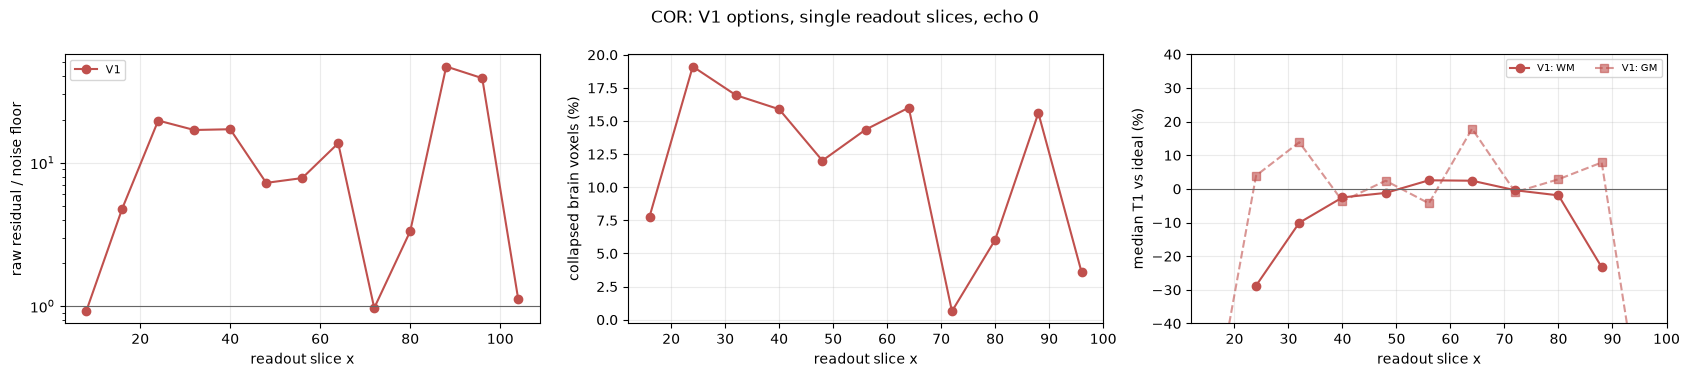

In [9]:
v1_screen = screen(V1_OPTS, tag='V1')
table(v1_screen)
plot_screens({'V1': v1_screen}, f'{PLANE}: V1 options, single readout slices, echo 0')

In moba's own residual metric (V1's log: the residual *entering* each Newton step) the
divergence looked peripheral. The raw-data residual after the last step shows it is broader:
**10 of 13 slices are broken** (residual 3-90× the noise floor, 4-19 % collapsed brain voxels),
central ones included (x = 56, 64); only x = 72 and the scalp-only slices x = 8 and 104 fit the
data. The last column is the data scale `--normalize_scaling` applied to each slice (7c).

### 7b. What goes wrong: the Newton steps of one slice

`moba` is deterministic (fixed random wavelet shifts, fixed α and FISTA schedules), so a run
with `-i k` is exactly the state after k Newton steps. Slice x = 56 (central) with V1's
options, k = 1 … 8: residual, the number of voxels where R1* sits at its bound 0 (by tissue
label: fat, bone, CSF, GM, WM, and the background), and the largest |M_ss|.

step   alpha FISTA res/noise  R1*=0 voxels: fat bone CSF  GM  WM   bg  max|Mss|        where
    1  1.000    10      5.47     0    0    0    0    0     0        0.9       bg  (16, 10)
    2  0.505    20      4.42     0    8    0    0    0     0        9.0  label 5  (47, 22)
    3  0.258    40      2.58     0    0    0    0    0     1        8.0  label 1   (23, 8)
    4  0.134    80      3.51     1   16    9   14   27   110       22.7  label 5  (40, 11)
    5  0.072   100      1.76     0    8    3    1    2    83       24.6  label 1   (62, 4)
    6  0.041   100      1.25     0    4    1    1    1    60       26.6  label 1   (62, 4)
    7  0.025   100      1.42     1   21   10    1    6   195       29.3  label 1   (62, 4)
    8  0.018   100      7.81    36   57   41   56  110   597       60.2       bg   (1, 42)


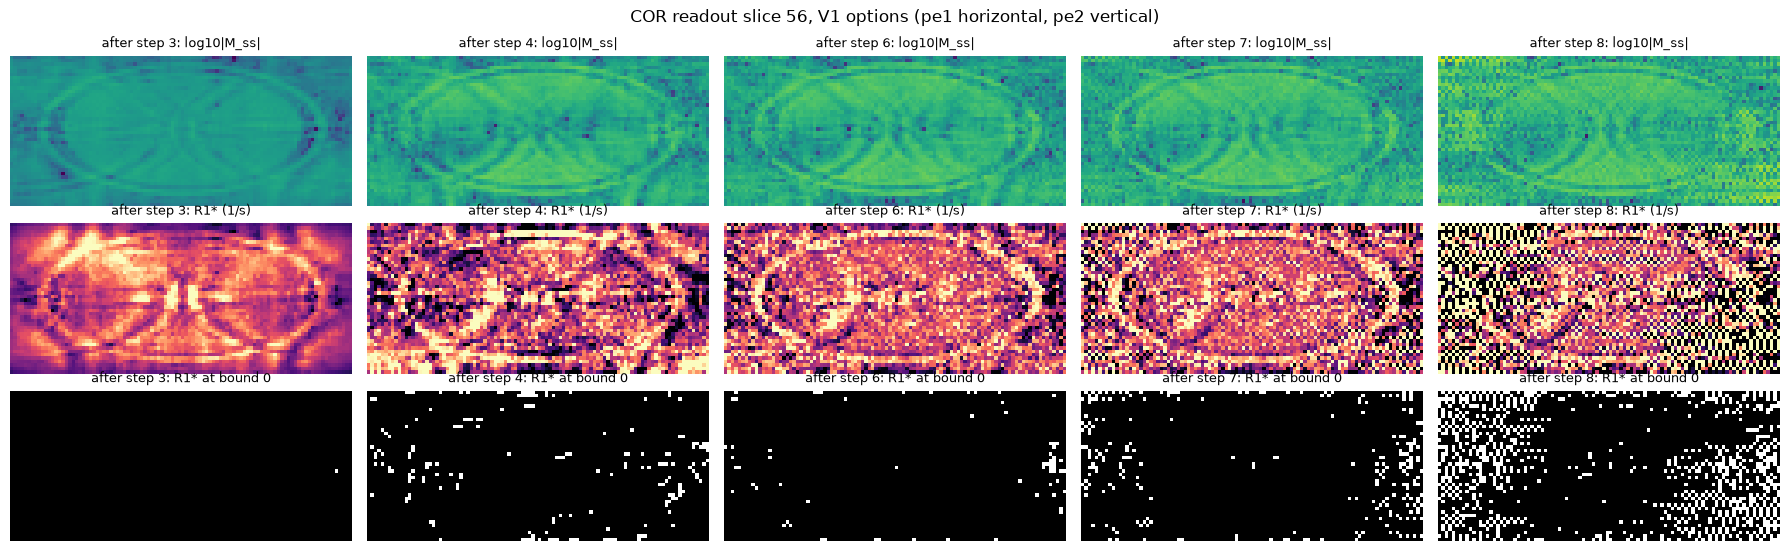

In [10]:
V1_BASE = '-L -l1 -C 100 -j 0.01 --normalize_scaling --scale_data 5000 --scale_psf 1000'
trace = ds.run_many([dict(plane=PLANE, x=56, opts=f'{V1_BASE} -i {k}', e=0, tag=f'i={k}') for k in range(1, 9)],
                    verbose=False)
lab56 = truth['label'][56]
print(f"{'step':5s} {'alpha':>6s} {'FISTA':>5s} {'res/noise':>9s} {'R1*=0 voxels: fat bone CSF  GM  WM   bg':>40s} {'max|Mss|':>9s} {'where':>12s}")
for k, r in enumerate(trace, start=1):
    R1 = np.real(r['maps'][..., 2]); A = np.abs(r['maps'][..., 0]); at0 = R1 <= 1e-3
    i = np.unravel_index(np.argmax(A), A.shape)
    alpha = 0.01 + 0.99 / 2 ** (k - 1)
    print(f"{k:5d} {alpha:6.3f} {min(100, 10 * 2 ** (k - 1)):5d} {r['final_res'] / r['noise_floor']:9.2f}  "
          + ' '.join(f'{int((at0 & (lab56 == l)).sum()):4d}' for l in range(1, 6)) + f' {int((at0 & (lab56 == 0)).sum()):5d}'
          + f"  {A.max():9.1f} {'bg' if lab56[i] == 0 else 'label %d' % lab56[i]:>8s} {str(tuple(int(v) for v in i)):>9s}")

fig, axes = plt.subplots(3, 5, figsize=(18, 5.6))
for c_, k in enumerate((3, 4, 6, 7, 8)):
    m = trace[k - 1]['maps']
    for r_, (v, ttl, kw) in enumerate(((np.log10(np.abs(m[..., 0]) + 1e-3), 'log10|M_ss|', dict(vmin=-1, vmax=2)),
                                       (np.real(m[..., 2]), 'R1* (1/s)', dict(vmin=0, vmax=6, cmap='magma')),
                                       (np.real(m[..., 2]) <= 1e-3, 'R1* at bound 0', dict(cmap='gray')))):
        axes[r_, c_].imshow(v.T, origin='lower', **kw); axes[r_, c_].axis('off')
        axes[r_, c_].set_title(f'after step {k}: {ttl}', fontsize=9)
plt.suptitle(f'{PLANE} readout slice 56, V1 options (pe1 horizontal, pe2 vertical)'); plt.tight_layout(); plt.show()

**Mechanism.** The residual falls until step 6-7 and then jumps above the data norm in the
last step, while R1* hits its bound 0 in hundreds of voxels of *every* tissue and of the
background (so this is not a long-T1/CSF effect), and the largest |M_ss| sits in the
background near the edge of the FOV. Two properties of the solver combine:

1. **A null space at the bound.** At R1* = 0 the model is S(TI) = −M0' for every TI, so
   ∂S/∂M_ss = 1 − e^(−TI·R1*) = 0: M_ss drops out of the data term and is held only by the
   (by then weak) wavelet penalty. It drifts; when a later update moves R1* off zero, the
   inflated M_ss appears in the forward model at once.
2. **No step control.** Each Newton step's linearised problem is solved for x_{n+1}
   directly (`irgnm2`), and with `-l1` the maps have no quadratic (proximal) term — only the
   coils do (α‖ĉ‖²). What limits a step is α_n and FISTA's iteration cap min(C, 10·2^n),
   i.e. early stopping. Late steps (α → α_min, 100 FISTA iterations) can therefore take
   large, poorly constrained steps. (This also explains two later observations: more FISTA
   iterations, `-C 200`, *destabilise* a borderline slice; and BART's damped update
   `--pusteps/--ratio` does not help, because the overshoot happens inside one linearised
   solve.)

The next three subsections are the three changes that remove it.

### 7c. Data scaling: per-slice normalisation gives noisy slices the least regularisation

`--normalize_scaling --scale_data 5000` rescales **each slice's** gridded data to norm 5000.
The noise SD σ is the same in every slice, but the signal is not: peripheral slices hold a
small cross-section of the head, so noise is a large part of their norm (noise floor 0.39 at
x = 26 vs 0.16 at x = 76) and their scale factor is large (s_data ≈ 100 vs ≈ 41). In moba's
units their noise is then ~2.5× larger than in central slices, against the **same** α — the
least informative slices get the weakest effective regularisation.

With a noise-referenced, fixed scale the ratio of regulariser to noise is the same in every
slice: in moba's units the maps are (s_data/s_psf) × the true maps, so for the M-maps the
l1 term relative to the data term scales as α/s_data, and relative to the noise as
α/(s_data·σ). Keeping **s_data·σ constant** keeps that ratio fixed across slices and planes.
V2 uses `--scale_data K/σ` with K = 4.545 (= 45 in the coronal plane, the value V1's
normalisation gave central slices) and `--scale_psf` = moba's own PSF normalisation
(1000/‖PSF‖, identical for every slice of a plane). A side benefit: the maps of all slices are
on one intensity scale (V1 needed a per-slice `rel_scale`). This also removes the reason V1
gave for 3D failing (the fixed-norm scaling did not adapt to volume size); 3D is not retried
here (tuning plan, section 18).

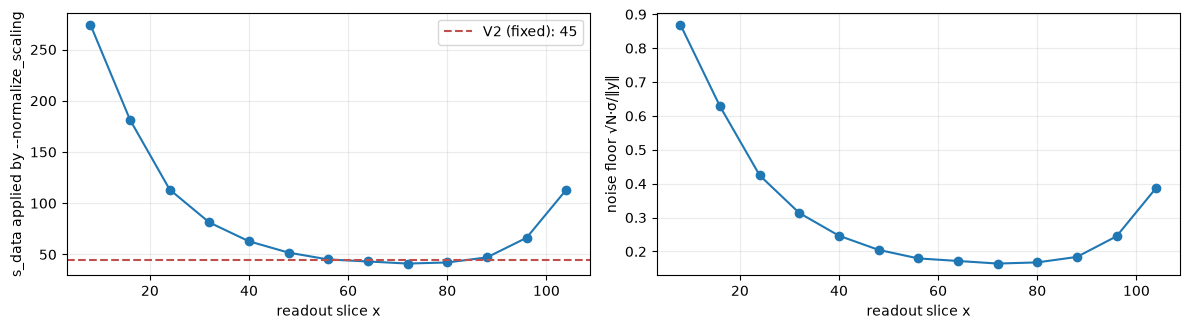

                            x res/noise  coll%  WM med/ideal  GM med/ideal  s_data
V1 (normalised)            26     23.33   14.6    208/260       282/304      102.9
V1 (normalised)            56      7.81   14.3    266/260       303/317       45.1
V1 (normalised)            93     87.04   10.1    129/262       228/298       56.0
fixed scaling, j 0.01      26      1.35    2.0    216/260       306/304       45.0
fixed scaling, j 0.01      56      8.10   14.8    266/260       304/317       45.0
fixed scaling, j 0.01      93    147.26   15.2    138/262       242/298       45.0
fixed scaling, j 0.1       26      0.92    0.2    224/260       293/304       45.0
fixed scaling, j 0.1       56      1.08    0.2    256/260       291/317       45.0
fixed scaling, j 0.1       93      5.33    7.1    152/262       269/298       45.0


In [11]:
x_ = [r['x'] for r in v1_screen]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(x_, [r['scale_data'] for r in v1_screen], 'o-'); ax[0].axhline(45, color='#c0504d', ls='--', label='V2 (fixed): 45')
ax[0].set_ylabel('s_data applied by --normalize_scaling'); ax[0].legend()
ax[1].plot(x_, [r['noise_floor'] for r in v1_screen], 'o-'); ax[1].set_ylabel('noise floor √N·σ/‖y‖')
for a in ax:
    a.set_xlabel('readout slice x'); a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

FIX = '-L -l1 -i 8 -C 100 -j 0.01 --scale_data 45 --scale_psf 17.971312'
cmp = []
for lab, o in (('V1 (normalised)', V1_OPTS), ('fixed scaling, j 0.01', FIX), ('fixed scaling, j 0.1', FIX.replace('-j 0.01', '-j 0.1'))):
    cmp += ds.run_many([dict(plane=PLANE, x=x, opts=o, e=0, tag=lab) for x in (26, 56, 93)], verbose=False)
table(cmp)

Fixed scaling alone improves the bottom slice (x = 26: residual 23 → 1.35 × noise floor) but is
not sufficient; with α_min = 0.1 the bottom and central slices converge, the top slice (x = 93)
still diverges, and where it converges (α_min 0.2-0.3, 7f) its WM T1 is far too low.

### 7d. The coil model: `--sobolev_a`

Where x = 93 converges (fixed scaling, α_min 0.2-0.3) WM comes out 15-30 % short. Three checks
show this is moba's coil estimation, not the data:

1. **Oracle:** per-TI SENSE (`pics`, l1-wavelet) with the *true* coil maps, PSIR and the
   grid fit gets WM and GM right in the same slices (table below).
2. **Intensity:** |M_ss| × coil RSS should be one constant × M0 × true RSS in every slice.
   With the default coil model it is ~14-15 in central slices but only 6-8 in the top slices
   — the image × coil product loses half of the brain signal there.
3. **Representation:** round-tripping the *true* coils through moba's coil model (section 6)
   leaves 10-13 % error with the default `a = 880`, 4-6 % with `a = 220`, ~2-3 % with 55.

In [12]:
# (1) oracle: per-TI SENSE with the true coils + PSIR grid fit (pipeline_utils.fit_t1_grid)
Dx_, T2_, TI_f_, info_ = ds.prepare(PLANE, 0)
print('per-TI pics -R W:6:0:0.002 with the TRUE coils, PSIR, grid fit (median T1 / ideal, ms):')
for x in (26, 56, 76, 90, 93):
    sens_x = pu.unit_rss(truth['sens'][x][None])
    X = []
    for j in range(4):
        im, log, err = ds.bart_quiet(1, 'pics -e -S -R W:6:0:0.002 -i 100', np.ascontiguousarray(Dx_[:, x:x + 1, ..., j:j + 1]),
                                     sens_x, t=np.ascontiguousarray(T2_[..., j:j + 1]))
        X.append(np.squeeze(im))
    X = np.stack(X, -1)
    S = np.real(X * np.conj(X[..., -1:]) / np.maximum(np.abs(X[..., -1:]), 1e-9))
    T1o, _, _ = pu.fit_t1_grid(S[None], info_['TI'], info_['TR'], (truth['label'][x] >= 3)[None])
    lab = truth['label'][x]; ide = truth['T1_ideal_ms'][x]
    print(f'  x={x:3d}: ' + '  '.join(f"{n} {np.median(1000 * T1o[0][lab == l]):.0f}/{np.median(ide[lab == l]):.0f}"
                                     for l, n in ((5, 'WM'), (4, 'GM'))))

# (3) representation error of moba's coil model for the true coils
ny_, nz_ = info_['matrix'][1:]
crop2 = lambda a: a[0, ny_ - ny_ // 2: ny_ - ny_ // 2 + ny_, nz_ - nz_ // 2: nz_ - nz_ // 2 + nz_]
sob_default = ds.sobolev_weights
print('\nrelative error of the true coils after moba\'s coil model (inside the head):')
for a_ in (880., 220., 55.):
    ds.sobolev_weights = lambda n1, n2, a=a_: sob_default(n1, n2, a=a)
    errs = []
    for x in (26, 56, 76, 93):
        m = truth['sens'][x]; hd = truth['label'][x] >= 1
        back = crop2(ds.coils_from_ksp(ds.ksp_from_coils(m, 1e-3)))
        errs.append(np.linalg.norm((back - m)[hd]) / np.linalg.norm(m[hd]))
    print(f'  sobolev_a {a_:5.0f}: ' + '  '.join(f'x={x}: {v:.3f}' for x, v in zip((26, 56, 76, 93), errs)))
ds.sobolev_weights = sob_default

per-TI pics -R W:6:0:0.002 with the TRUE coils, PSIR, grid fit (median T1 / ideal, ms):


  x= 26: WM 255/260  GM 312/304


  x= 56: WM 261/260  GM 310/317


  x= 76: WM 262/261  GM 313/312


  x= 90: WM 260/259  GM 302/297


  x= 93: WM 272/262  GM 298/298

relative error of the true coils after moba's coil model (inside the head):


  sobolev_a   880: x=26: 0.104  x=56: 0.131  x=76: 0.119  x=93: 0.112


  sobolev_a   220: x=26: 0.053  x=56: 0.059  x=76: 0.049  x=93: 0.035


  sobolev_a    55: x=26: 0.027  x=56: 0.028  x=76: 0.023  x=93: 0.017


In [13]:
# (2) + the effect on T1: default coil model vs a = 220 vs oracle coil initialisation (a = 880)
B = '-L -l1 -C 100 -j 0.3 -i 10 --scale_data 45 --scale_psf 17.971312'
xs5 = (26, 56, 76, 90, 93)
ks = {x: ds.ksp_from_coils(0.6 * truth['sens'][x], 1e-3) for x in xs5}   # 0.6: moba's typical coil RSS
runs = {}
runs['a = 880 (default)'] = ds.run_many([dict(plane=PLANE, x=x, opts='-L -l1 -C 100 --scale_data 45 --scale_psf 17.971312 -j 0.3 -i 10',
                                              tag='a 880') for x in xs5], verbose=False)
runs['a = 880, true-coil init'] = ds.run_many([dict(plane=PLANE, x=x, opts=B, tag='a 880 true init', ksp_sens=ks[x],
                                                    ksp_tag='true0.6_t1e-3') for x in xs5], verbose=False)
runs['a = 220'] = ds.run_many([dict(plane=PLANE, x=x, opts=B + ' --sobolev_a 220', tag='a 220') for x in xs5], verbose=False)


def intensity_ratio(r):
    x = r['x']; hd = truth['label'][x] >= 3
    rss = np.sqrt((np.abs(r['sens']) ** 2).sum(-1)); trss = np.sqrt((np.abs(truth['sens'][x]) ** 2).sum(-1))
    return np.median((np.abs(r['maps'][..., 0]) * rss / np.maximum(truth['M0'][x] * trss, 1e-6))[hd])


print(f"{'':26s} " + ''.join(f'{"x=%d" % x:>22s}' for x in xs5))
for lab, rr in runs.items():
    print(f'{lab:26s} ' + ''.join(f"{intensity_ratio(r):5.1f} {r['rows']['WM']['med']:4.0f}/{r['rows']['WM']['ideal']:<4.0f}"
                                  f"{r['final_res'] / r['noise_floor']:5.2f}".rjust(22) for r in rr))
print('columns: intensity ratio |M_ss|·RSS/(M0·RSS_true), WM median/ideal (ms), residual/noise')

                                             x=26                  x=56                  x=76                  x=90                  x=93
a = 880 (default)             11.7  235/260  0.96   15.1  254/260  1.08   13.8  256/261  1.07    8.1  221/259  1.04    6.0  194/262  1.06
a = 880, true-coil init       16.9  247/260  0.96   15.5  250/260  1.06   14.2  247/261  1.09   12.2  226/259  1.05   11.7  229/262  1.02
a = 220                       18.5  254/260  0.89   17.3  258/260  0.87   17.9  260/261  0.88   17.3  247/259  0.88   16.4  249/262  0.89
columns: intensity ratio |M_ss|·RSS/(M0·RSS_true), WM median/ideal (ms), residual/noise


With `a = 220` the intensity ratio is uniform across slices (16-18), WM is within ~5 % of
ideal in every test slice (x = 93: 249 vs 262 ms; default: 194), GM improves, and the residual
reaches the noise floor. The oracle coil *initialisation* with the default coil model helps
much less — the limit was the representable coil space, not the starting point.

### 7e. α_min: where the stability boundary is

With fixed scaling and `a = 220`, the 13-slice screen for both echo groups at α_min = 0.3 (V2)
and 0.1:

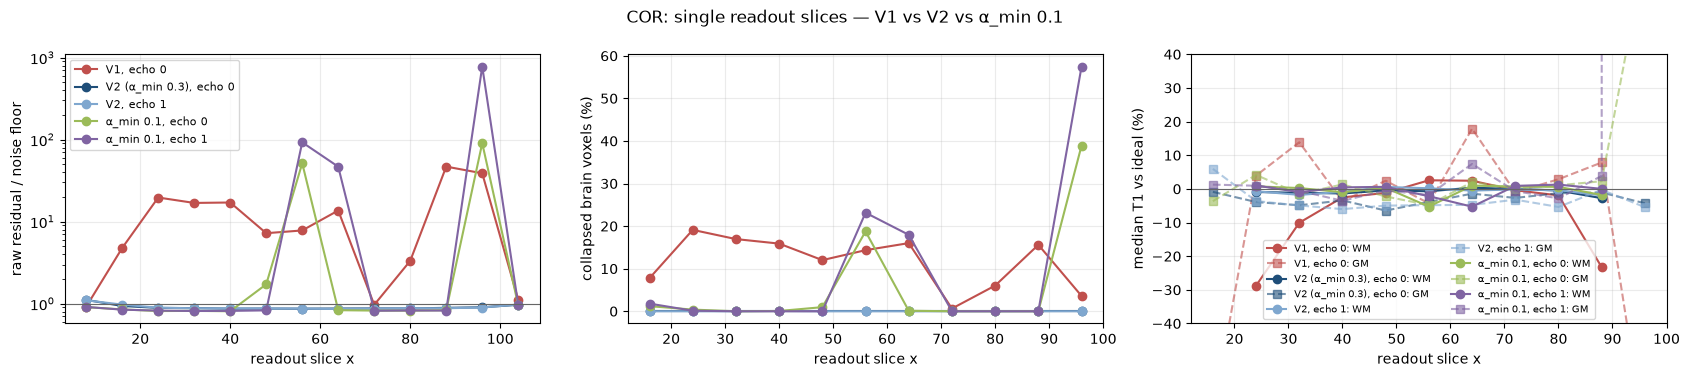

V2            : diverged (residual > 1.5 x noise floor) in 0/26 slice runs []
alpha_min 0.1 : diverged (residual > 1.5 x noise floor) in 6/26 slice runs ['x=48 e0', 'x=56 e0', 'x=96 e0', 'x=56 e1', 'x=64 e1', 'x=96 e1']


In [14]:
v2_screen = {e: screen(V2_SLICE, e, tag=f'V2 e{e}') for e in (0, 1)}
j01_screen = {e: screen(V2_SLICE.replace('-j 0.3', '-j 0.1'), e, tag=f'j0.1 e{e}') for e in (0, 1)}
plot_screens({'V1, echo 0': v1_screen, 'V2 (α_min 0.3), echo 0': v2_screen[0], 'V2, echo 1': v2_screen[1],
              'α_min 0.1, echo 0': j01_screen[0], 'α_min 0.1, echo 1': j01_screen[1]},
             f'{PLANE}: single readout slices — V1 vs V2 vs α_min 0.1')
for lab, s in (('V2', v2_screen), ('alpha_min 0.1', j01_screen)):
    rr = s[0] + s[1]
    bad = [f"x={r['x']} e{r['e']}" for r in rr if r['final_res'] > 1.5 * r['noise_floor']]
    print(f"{lab:14s}: diverged (residual > 1.5 x noise floor) in {len(bad)}/{len(rr)} slice runs {bad}")

At α_min = 0.3 every slice of both echo groups converges (residual 0.85-0.9 × noise floor,
no collapsed voxels, WM within ~3 % of ideal; the scalp-only slice x = 8 sits ~10 % above its
floor). At α_min = 0.1 the maps are sharper where it converges (GM closer to ideal), but
6 of 26 slice runs diverge (x = 48, 56, 64, 96). **V2 takes 0.3**, leaving margin; locating the boundary between 0.1
and 0.3 (or making α_min adaptive per slice) is the first tuning stage.

### 7f. Levers that did not help (or did not transfer)

For completeness, the other candidate levers from the V1 report, on the bottom (26), central
(56) and top (93) test slices, echo 0. Each row changes one thing relative to the
configuration named in its label.

In [15]:
F = '--scale_data 45 --scale_psf 17.971312'
LEVERS = [
    ('V1', V1_OPTS),
    ('V1 + lower bound -B 0.3', V1_OPTS + ' -B 0.3'),
    ('V1 + l2 on M_ss', V1_OPTS + ' --l2-on-parameters 1'),
    ('V1 + j 0.1', V1_OPTS.replace('-j 0.01', '-j 0.1')),
    ('fixed, j 0.1 + auto-norm -N', f'-L -l1 -C 100 -j 0.1 {F} -i 8 -N'),
    ('fixed, j 0.2', f'-L -l1 -C 100 -j 0.2 {F} -i 8'),
    ('fixed, j 0.2 + init R1* 3', f'-L -l1 -C 100 -j 0.2 {F} -i 8 --other pinit=1:1:3'),
    ('fixed, j 0.2 + -C 200', f'-L -l1 -C 200 -j 0.2 {F} -i 8'),
    ('fixed, j 0.2 i10 + pusteps r 0.5', f'-L -l1 -C 100 {F} -j 0.2 -i 10 --pusteps 10 --ratio 0.5'),
    ('fixed, j 0.3 i10 (a 880)', f'-L -l1 -C 100 {F} -j 0.3 -i 10'),
    ('fixed, j 0.3 i10, a 220 (V2)', f'-L -l1 -C 100 -j 0.3 -i 10 {F} --sobolev_a 220'),
]
lev = {lab: ds.run_many([dict(plane=PLANE, x=x, opts=o, tag=lab) for x in (26, 56, 93)], verbose=False) for lab, o in LEVERS}
print(f"{'':34s}" + ''.join(f"{'x=%d: res/noise coll%%  WM   GM' % x:>34s}" for x in (26, 56, 93)))
for lab, rr in lev.items():
    print(f'{lab:34s}' + ''.join(f"{r['final_res'] / r['noise_floor']:9.2f} {100 * r['rows']['collapsed_frac']:5.1f} "
                                 f"{r['rows']['WM']['med']:5.0f} {r['rows']['GM']['med']:5.0f}".rjust(34) for r in rr))
print('ideal (ms):' + ' ' * 23 + ''.join(f"{truth_ideal:>34s}" for truth_ideal in
      [f"WM {lev['V1'][i]['rows']['WM']['ideal']:.0f} GM {lev['V1'][i]['rows']['GM']['ideal']:.0f}" for i in range(3)]))

                                      x=26: res/noise coll%  WM   GM    x=56: res/noise coll%  WM   GM    x=93: res/noise coll%  WM   GM
V1                                           23.33  14.6   208   282            7.81  14.3   266   303           87.04  10.1   129   228
V1 + lower bound -B 0.3                      51.13  14.3   195   275           25.86  24.2   271   319           84.39  16.5   106   212
V1 + l2 on M_ss                              15.37  14.3   220   264            2.57   3.3   249   290           64.62  32.7   214   336
V1 + j 0.1                                   14.20  14.4   218   332            1.08   0.2   256   291           48.35  18.7   136   268
fixed, j 0.1 + auto-norm -N                   2.56  61.4  1831  1390            4.17  22.6   576   816            2.75   0.0   251   287
fixed, j 0.2                                  0.95   0.3   227   287            1.10   0.1   255   282            1.07   0.0   173   279
fixed, j 0.2 + init R1* 3                

* **Lower bound `-B`** (R1* ≥ 0.3 s⁻¹): voxels drift to the bound instead of to 0; no help.
* **l2 on M_ss** (`--l2-on-parameters 1`): damps the null space but biases the curve and
  destabilises the top slice.
* **`-N`** (per-map normalisation before thresholding): worse.
* **Initial R1* = 3 s⁻¹** (`--other pinit=1:1:3`): speeds up WM convergence at the top of
  the head (default init overshoots to T1 ≈ 70 ms after step 2 there and creeps back) but
  biases the long-T1 lesion low and does not survive more iterations; not needed with `a = 220`.
* **`-C 200`, damped updates (`--pusteps/--ratio`)**: more inner iterations destabilise a
  borderline slice; damping does not help (7b).
* **`--other pscale`** is *not* a valid lever for `-L` in BART v1.0.00: the T1 model is
  built with fixed scalings (`T1_create(..., conf->scaling_M0, conf->scaling_R1s, ...)` = 1),
  and `pscale` only divides the initial value and multiplies the output — the returned R1*
  would simply be wrong by that factor. The equivalent lever is the unit of the TI file
  (TI × k makes moba estimate R1*/k); it was not needed, because M_ss ≈ 10 and R1* ≈ 4 s⁻¹
  already give Jacobian columns of similar size.
* **Step size `-s`**: not tested separately; it only changes FISTA's step relative to 1/L
  (default 0.9), i.e. acts like the iteration cap.

### 7g. V2 configuration

`-L -l1 -i 10 -C 100 -j 0.3 --sobolev_a 220 --scale_data K/σ --scale_psf 1000/‖PSF‖`
(K = 4.545). Slice-wise along the readout as in V1. The price of stability is
regularisation: α_min = 0.3 smooths more than V1 intended, which is expected to show as
partial-volume-like bias at small lesions and GM (section 11) — the subject of tuning.

## 8. `moba -L` reconstruction per echo group (full plane)

All four TIs of one echo group go into one `moba -L` problem: phase-demodulated k-space,
TI file (seconds), trajectory as wrapper keyword `t=T`, no `-p`.

**Slice-wise along the readout (as in V1).** The readout is fully sampled and Cartesian
(`traj[0]` = integer positions −n/2 … n/2−1), so an inverse FFT along the readout decouples
the 3D problem *exactly* into independent 2D problems, one per readout position, each with the
(pe1, pe2) trajectory of the scan. Each 2D problem is solved by `moba`
(`--img_dims 1:ny:nz`), and the slices are stacked. Regularisation and coil smoothness act
within each (pe1, pe2) plane only.

**Scaling (V2).** `--scale_psf` is moba's own PSF normalisation (1000/‖PSF‖; read from a
one-step moba run on the central slice, identical for all slices of a plane) and
`--scale_data` = K/σ with σ the plane's k-space noise SD (`info['noise_sd']`; on real data it
must be estimated, e.g. from the noise scan or the k-space periphery). moba's image × coil
product is then the true image × 2·s_data/s_psf in every slice (`rel_scale` = its inverse).

With a trajectory `moba` works on a **2× oversampled grid** and restricts the maps to the
central half (`-f 0.5` default for non-Cartesian): maps and coils are cropped to the central
(ny, nz). **Per-slice convergence check (new):** after each slice, the raw-data residual and
its noise floor (section 7) are stored; a slice whose residual exceeds 1.5× its noise floor
is flagged as diverged.

In [16]:
def ti_file(scans_plane):
    return np.array([s['info']['TI_s'] for s in scans_plane], np.complex64).reshape(1, 1, 1, 1, 1, -1)


def plane_scaling(Dx, T2, TI_f, matrix, noise_sd):
    # s_psf: moba's own PSF normalisation (1000/||PSF||), read from a one-step run on the central
    # slice (the PSF is the same for every slice); s_data: noise-referenced, NOISE_REF_SCALE / sigma
    nx, ny, nz = matrix
    _, log, err = ds.bart_quiet(2, f'moba -L -i 1 -C 5 --normalize_scaling --scale_data 5000 --scale_psf 1000 '
                                   f'--img_dims 1:{ny}:{nz}', np.ascontiguousarray(Dx[:, nx // 2:nx // 2 + 1]), TI_f, t=T2)
    s_psf = float(re.findall(r'Scaling_psf: ([0-9.eE+-]+)', log)[-1])
    return NOISE_REF_SCALE / noise_sd, s_psf


def moba_slice(Dx, T2, TI_f, ny, nz, cmd, info_slice):
    res, log, err = ds.bart_quiet(2, cmd, Dx, TI_f, t=T2)
    if err or res is None:
        raise RuntimeError(f'moba failed ({err}):\n{log[-2000:]}')
    x, s = [np.squeeze(a) for a in res]                              # (2ny, 2nz, 3), (2ny, 2nz, coil)
    crop = lambda a: a[ny - ny // 2: ny - ny // 2 + ny, nz - nz // 2: nz - nz // 2 + nz]
    num = lambda key: float(re.findall(rf'{key}: ([0-9.eE+-]+)', log)[-1])
    r = dict(maps=crop(x).astype(np.complex64), sens=crop(s).astype(np.complex64),
             scale_data=num('Scaling'), scale_psf=num('Scaling_psf'),
             steps=np.array([float(v) for v in re.findall(r'Step: \d+, Res: ([0-9.eE+-]+)', log)]))
    r['final_res'], r['noise_floor'] = ds.data_residual(r, Dx, T2, info_slice)
    with open(PROC_DIR / 'moba_progress.log', 'a') as fh:          # progress of long runs (one line per slice)
        fh.write(f"{time.strftime('%H:%M:%S')} {info_slice['tag']} res/noise {r['final_res'] / r['noise_floor']:.2f}\n")
    return r


def moba_recon(scans_plane, e, plane):
    f = PROC_DIR / f'moba_{plane}_e{e}_{MOBA_TAG}.npz'
    if f.exists():
        return dict(np.load(f)), 'cached'
    info = scans_plane[pu.REF_TI_IDX]['info']
    matrix = info['matrix']
    nx, ny, nz = matrix
    T, D, P = pu.stack_tis(scans_plane, e)                   # P not passed: see section 4
    dphi = ti_phase_offsets(T, D, matrix) if PHASE_CORR else np.zeros(D.shape[5])
    D = (D * np.exp(-1j * dphi).reshape(1, 1, 1, 1, 1, -1)).astype(np.complex64)
    Dx = bart(1, 'fft -i -u 2', D)                           # readout k -> x (dim 1)
    if Dx is None or np.shape(Dx) != D.shape:
        raise RuntimeError('readout iFFT failed')
    T2 = T[:, :1].copy(); T2[0] = 0                          # (0, k_pe1, k_pe2) per sample
    TI_f = ti_file(scans_plane)
    s_data, s_psf = plane_scaling(Dx, T2, TI_f, matrix, info['noise_sd'])
    cmd = f'moba {MOBA_OPTS} --scale_data {s_data:.4f} --scale_psf {s_psf:.6f} -d 4 --img_dims 1:{ny}:{nz}'
    info_slice = dict(matrix=matrix, noise_sd=info['noise_sd'], TI=np.real(TI_f).ravel())
    t0 = time.time()
    with ThreadPoolExecutor(MOBA_JOBS) as ex:
        out = list(ex.map(lambda x: moba_slice(np.ascontiguousarray(Dx[:, x:x + 1]), T2, TI_f, ny, nz, cmd,
                                               dict(info_slice, tag=f'{plane} e{e} x={x}')), range(nx)))
    dt = time.time() - t0
    res = {k: np.stack([o[k] for o in out]) for k in ('maps', 'sens', 'scale_data', 'scale_psf', 'steps',
                                                      'final_res', 'noise_floor')}
    res.update(dphi=dphi, runtime_s=dt, cmd=cmd)
    res['rel_scale'] = 0.5 * res['scale_psf'] / res['scale_data']   # moba units -> data units
    np.savez(f, **res)
    return res, 'reconstructed'


rec = {}
for e in (0, 1):
    rec[PLANE, e], state = moba_recon(scans[PLANE], e, PLANE)
    r = rec[PLANE, e]
    q = r['final_res'] / r['noise_floor']
    print(f"{PLANE} echo {e}: {state}, {r['maps'].shape[0]} readout slices, "
          f"wall time {float(r['runtime_s']) / 60:.1f} min ({MOBA_JOBS} parallel jobs)\n  {r['cmd']}")
    print(f'  raw residual / noise floor per slice: median {np.median(q):.2f}, range {q.min():.2f}-{q.max():.2f}; '
          f'diverged (> 1.5): {int((q > 1.5).sum())} slices {np.flatnonzero(q > 1.5).tolist()}')

COR echo 0: cached, 112 readout slices, wall time 18.6 min (4 parallel jobs)
  moba -L -l1 -i 10 -C 100 -j 0.3 --sobolev_a 220 --scale_data 45.0027 --scale_psf 17.971312 -d 4 --img_dims 1:100:44
  raw residual / noise floor per slice: median 0.88, range 0.86-1.27; diverged (> 1.5): 0 slices []


COR echo 1: cached, 112 readout slices, wall time 16.2 min (4 parallel jobs)
  moba -L -l1 -i 10 -C 100 -j 0.3 --sobolev_a 220 --scale_data 45.0027 --scale_psf 17.971312 -d 4 --img_dims 1:100:44
  raw residual / noise floor per slice: median 0.88, range 0.86-1.25; diverged (> 1.5): 0 slices []


## 9. Convergence per slice and parameter maps

Top: the raw-data residual relative to the noise floor for every readout slice (both echo
groups) — the full-plane version of the section-7 screen. Then the maps, mid pe2 slice (the
1.8 × 1.8 mm in-plane view). With the fixed scaling, M_ss and M0' of all slices are on one
scale (moba units); their magnitude still carries the arbitrary image/coil split of the joint
estimation (the arcs in |M_ss| are the coil-map structure it absorbed; T1 is unaffected, R1*
being scale-free). Expected: R1* ≈ 3.8 s⁻¹ in WM, ≈ 3.2 in GM, ≈ 0.3 in CSF.

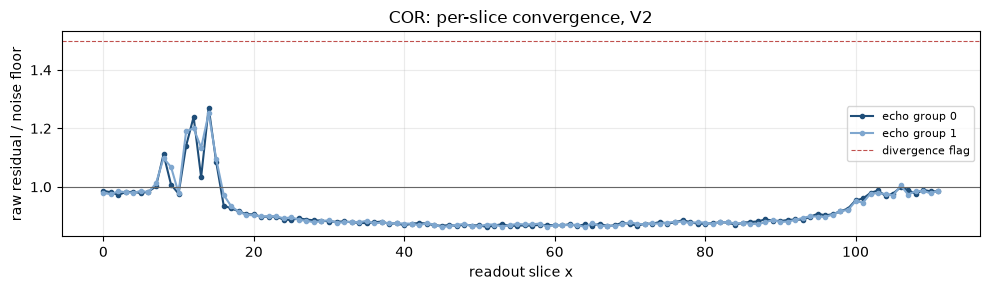

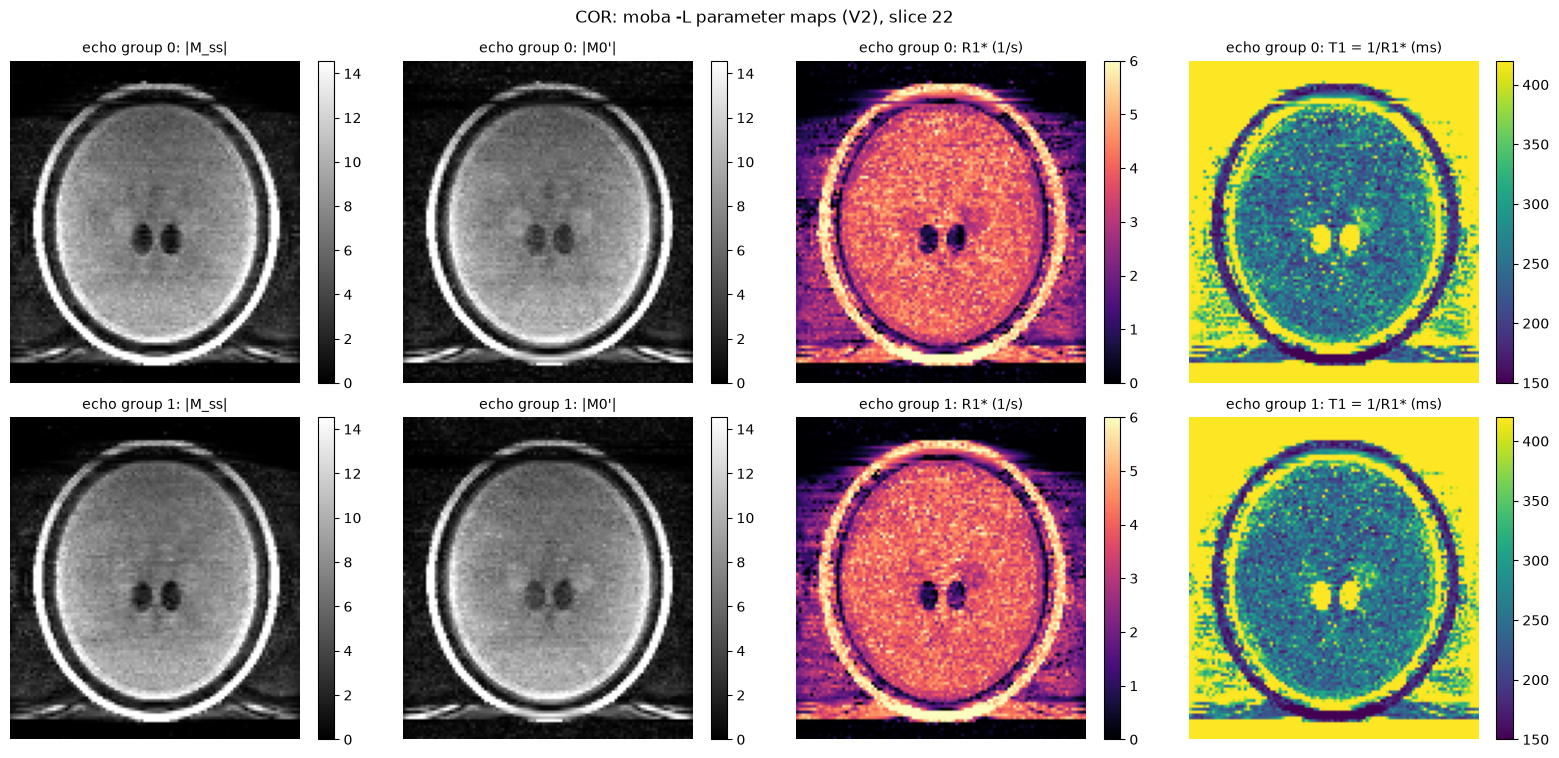

In [17]:
info = scans[PLANE][pu.REF_TI_IDX]['info']
sp = pu.spacing_of(info); ASP = sp[0] / sp[1]
head = truth['label'] >= 3                                     # CSF, GM, WM, lesions
z0 = info['matrix'][2] // 2

fig, ax = plt.subplots(figsize=(10, 3))
for e, col in ((0, '#1f4e79'), (1, '#7fa7cf')):
    r = rec[PLANE, e]
    ax.plot(r['final_res'] / r['noise_floor'], 'o-', ms=3, color=col, label=f'echo group {e}')
ax.axhline(1, color='0.4', lw=0.8); ax.axhline(1.5, color='#c0504d', lw=0.8, ls='--', label='divergence flag')
ax.set_xlabel('readout slice x'); ax.set_ylabel('raw residual / noise floor'); ax.legend(fontsize=8)
ax.grid(alpha=0.25); ax.set_title(f'{PLANE}: per-slice convergence, V2'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7.6))
for r_, e in enumerate((0, 1)):
    m = rec[PLANE, e]['maps']
    R1 = np.real(m[..., 2])
    vmax = np.percentile(np.abs(m[..., 0])[head], 99.5)
    panels = [(np.abs(m[..., 0]), '|M_ss|', dict(cmap='gray', vmin=0, vmax=vmax)),
              (np.abs(m[..., 1]), "|M0'|", dict(cmap='gray', vmin=0, vmax=vmax)),
              (R1, 'R1* (1/s)', dict(cmap='magma', vmin=0, vmax=6)),
              (1000 / np.maximum(R1, 1e-3), 'T1 = 1/R1* (ms)', dict(cmap='viridis', vmin=150, vmax=420))]
    for c_, (v, ttl, kw) in enumerate(panels):
        ax = axes[r_, c_]
        im = ax.imshow(v[:, :, z0], aspect=ASP, **kw)
        ax.set_title(f'echo group {e}: {ttl}', fontsize=10); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'{PLANE}: moba -L parameter maps (V2), slice {z0}'); plt.tight_layout(); plt.show()

## 10. T1 and echo-group combination

The LLR pipeline averages the *signed images* of the two echo groups before the fit. moba
never produces images, so the two echo groups are combined in the **parameter domain**:
both groups have the same sampling, the same noise and the same T1, only a different
phase, so they get **equal weight**, and the average is taken on **R1*** — the quantity
moba estimates (it is linear in the Gauss-Newton updates, and its noise is closer to
symmetric than that of T1 = 1/R1*): T1 = 1 / mean(R1*_e0, R1*_e1). (For the ~±5 %
differences seen here, the harmonic mean differs from the arithmetic mean of T1 by < 0.1 %.)
Weighting by |M_ss| is not possible across runs, because each run splits signal between
image and coils with its own scale. Both groups are also evaluated separately.

T1 is set to NaN outside the head label (≥ 3), the same mask the LLR reference fits in.

In [18]:
def t1_from(maps_list, mask):
    R1 = np.mean([np.real(m[..., 2]) for m in maps_list], axis=0)
    T1 = np.where(mask & (R1 > 0), 1.0 / np.maximum(R1, 1e-6), np.nan)      # seconds
    return T1.astype(np.float32)


T1_e = {e: t1_from([rec[PLANE, e]['maps']], head) for e in (0, 1)}
T1_moba = t1_from([rec[PLANE, e]['maps'] for e in (0, 1)], head)
d = 100 * (T1_e[1] - T1_e[0]) / T1_moba
print(f'echo 1 vs echo 0 T1 (voxel-wise, head): median {np.nanmedian(d):+.2f} %, '
      f'IQR {np.nanpercentile(d, 25):+.2f} .. {np.nanpercentile(d, 75):+.2f} %')

echo 1 vs echo 0 T1 (voxel-wise, head): median +0.22 %, IQR -15.20 .. +15.63 %


## 11. Validation against the truth

`pu.evaluate_t1`: eroded tissue masks and per-lesion masks; **bias vs ideal** (the
resolution-limited, noise-free, fully sampled reference) is the reconstruction's own error
and the number to compare methods on. Means are reported by `evaluate_t1`; with V2 they are no
longer dominated by collapsed voxels (V1: WM mean +134 %, median −3.6 %).

In [19]:
rows = pu.evaluate_t1(T1_moba, truth)
pu.print_eval(rows, f'\n{PLANE}: moba -L V2, echo groups combined ({ECHO_COMBINE}), {MOBA_TAG}')
rows_e = {}
for e in (0, 1):
    rows_e[e] = pu.evaluate_t1(T1_e[e], truth)
    pu.print_eval(rows_e[e], f'\n{PLANE}: moba -L V2, echo group {e} only')
from scipy.ndimage import binary_erosion
for l, n in ((5, 'WM'), (4, 'GM')):
    m = binary_erosion(truth['label'] == l) & np.isfinite(T1_moba)
    v = 1000 * T1_moba[m]
    print(f'{n}: median {np.median(v):.1f} ms (ideal median {np.median(truth["T1_ideal_ms"][m]):.1f}), '
          f'IQR {np.percentile(v, 25):.0f}-{np.percentile(v, 75):.0f}, T1 > 1 s in {100 * np.mean(v > 1000):.2f} % of voxels')


COR: moba -L V2, echo groups combined (mean_R1), v2_L-l1_i10_C100_j0.3_a220_k4.545_ph1
true = phantom T1; ideal = fit to fully sampled, noise-free, resolution-limited signal (partial volume only); bias vs ideal = reconstruction alone
region                 n    true   ideal     est     sd  bias% vs ideal% peak PV
WM                 70965   259.8   259.8   259.2   31.5   -0.2      -0.2 
GM                  3750   309.2   308.8   301.5   38.3   -2.5      -2.3 
CSF                  387  3543.2  3867.0 84275.1 1228522.5 2278.5    2079.3 
lesion 1 (10 mm)      34   338.0   313.7   306.4   41.7   -9.3      -2.3    1.00
lesion 2 (6 mm)       10   338.0   304.2   291.2   34.6  -13.8      -4.3    0.75
lesion 3 (4 mm)        4   338.0   293.1   301.2   16.5  -10.9       2.8    0.50
lesion 4 (2 mm)        1   338.0   268.3   281.4    0.0  -16.7       4.9    0.19
lesion 5 (10 mm)      34   182.0   203.9   209.9   28.4   15.3       2.9    1.00
lesion 6 (6 mm)        7   182.0   211.5   224.0   20.

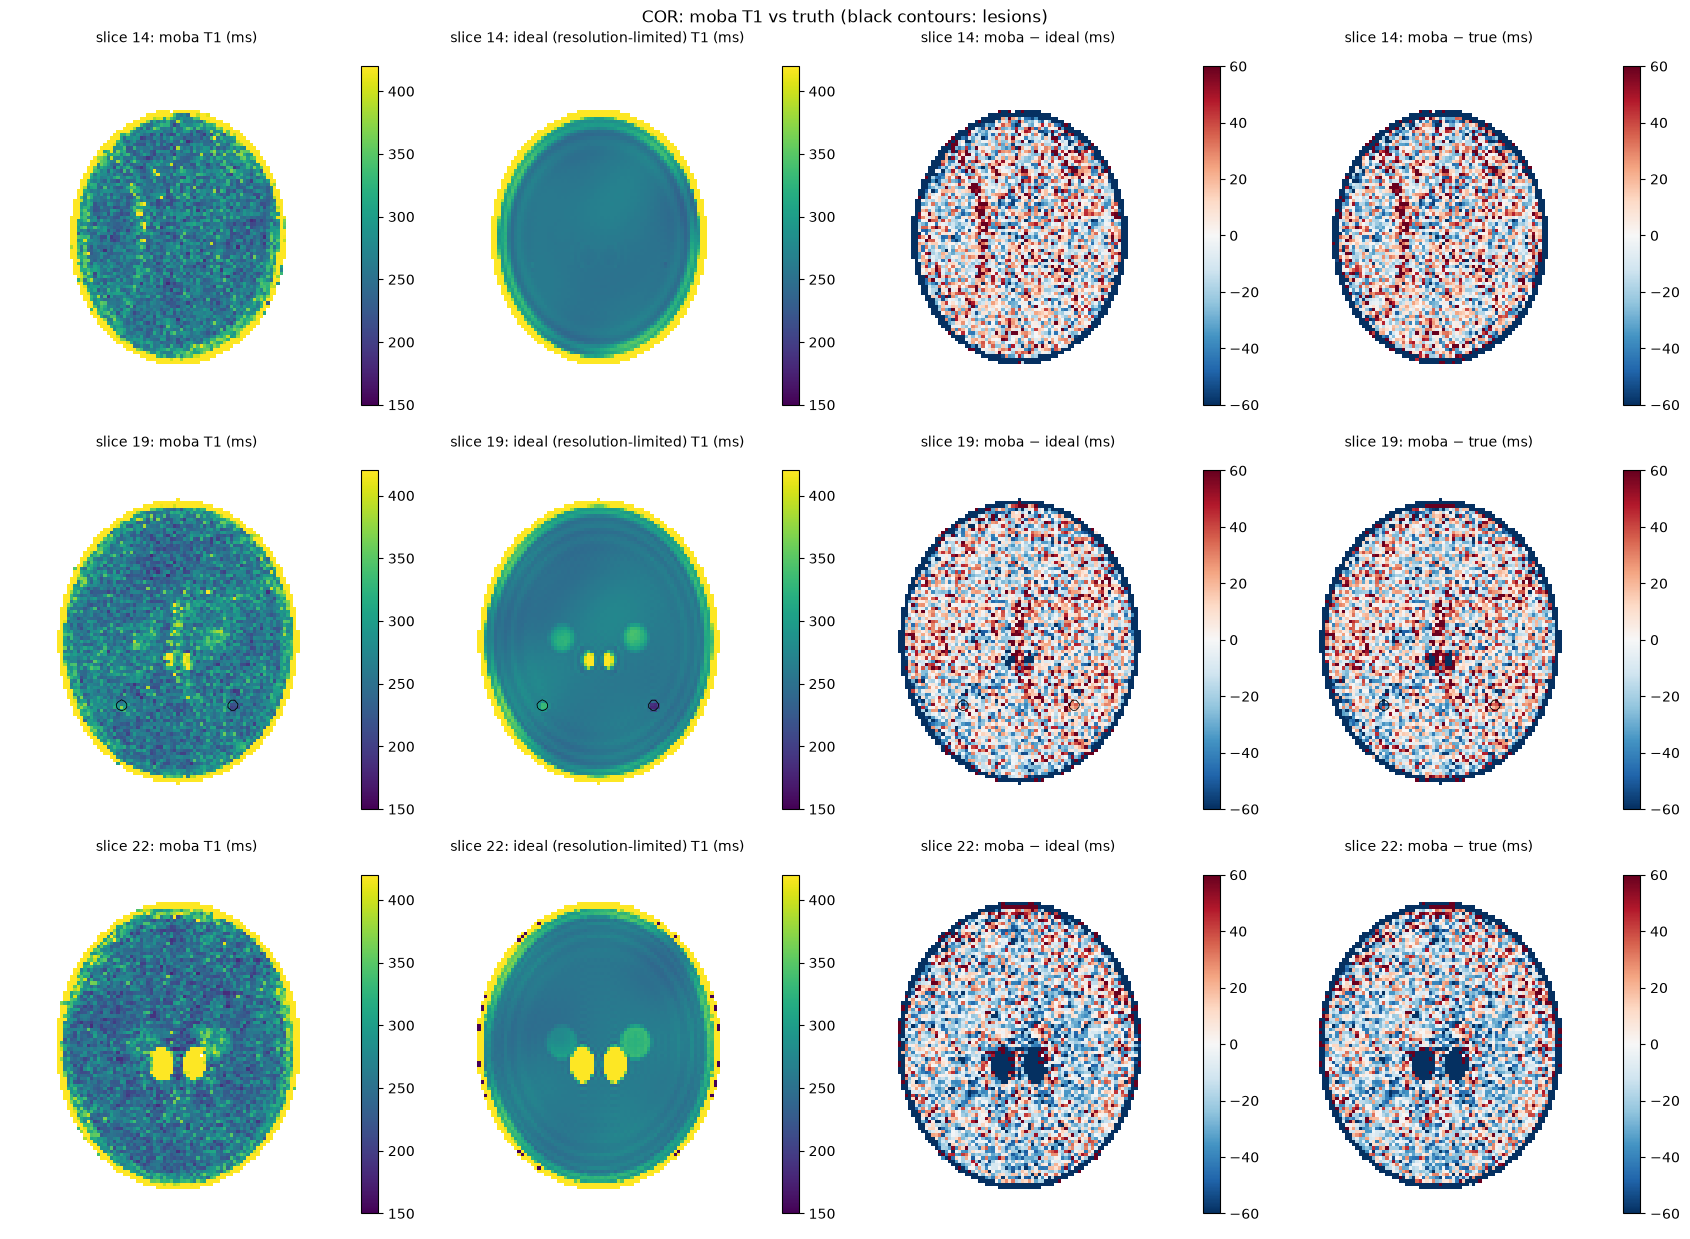

In [20]:
T1_true = truth['T1_ms']; T1_ideal = truth['T1_ideal_ms']
lesion_z = [int(np.argmax(fr.sum(axis=(0, 1)))) for fr in truth['lesion_frac_by_id']]
slices = sorted(set([z0] + lesion_z))[:3]
fig, axes = plt.subplots(len(slices), 4, figsize=(17, 4.2 * len(slices)))
axes = np.atleast_2d(axes)
for r_, z in enumerate(slices):
    for c_, (v, ttl, kw) in enumerate([
            (1000 * T1_moba[:, :, z], 'moba T1 (ms)', dict(cmap='viridis', vmin=150, vmax=420)),
            (T1_ideal[:, :, z], 'ideal (resolution-limited) T1 (ms)', dict(cmap='viridis', vmin=150, vmax=420)),
            (1000 * T1_moba[:, :, z] - T1_ideal[:, :, z], 'moba − ideal (ms)', dict(cmap='RdBu_r', vmin=-60, vmax=60)),
            (1000 * T1_moba[:, :, z] - T1_true[:, :, z], 'moba − true (ms)', dict(cmap='RdBu_r', vmin=-60, vmax=60))]):
        ax = axes[r_, c_]
        im = ax.imshow(np.where(head[:, :, z], v, np.nan), aspect=ASP, **kw)
        ax.contour(truth['lesion_fraction'][:, :, z], [0.25], colors='k', linewidths=0.6)
        ax.set_title(f'slice {z}: {ttl}', fontsize=10); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'{PLANE}: moba T1 vs truth (black contours: lesions)'); plt.tight_layout(); plt.show()

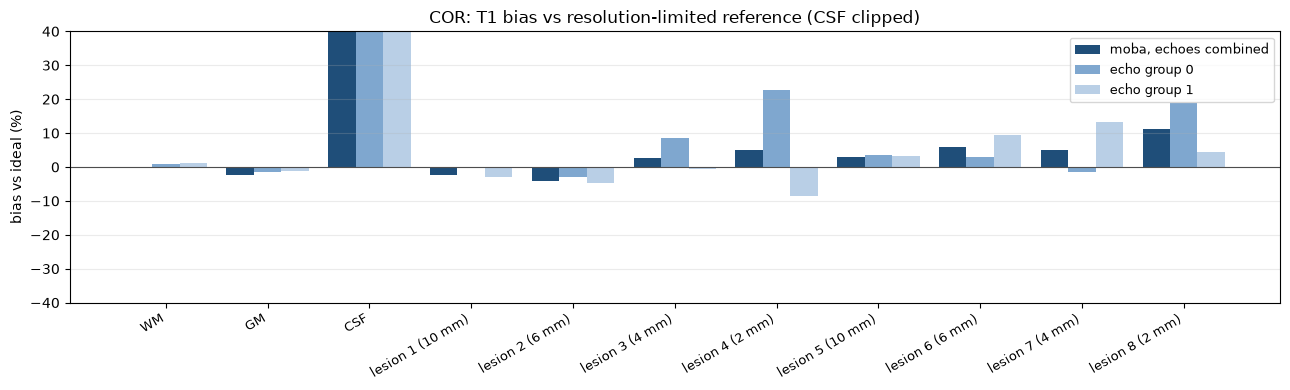

In [21]:
# Bias vs ideal per region, moba (combined) and each echo group
names = [r['region'] for r in rows]
x = np.arange(len(names)); wdt = 0.27
fig, ax = plt.subplots(figsize=(13, 4))
for k, (lab, rr, col) in enumerate((('moba, echoes combined', rows, '#1f4e79'),
                                     ('echo group 0', rows_e[0], '#7fa7cf'),
                                     ('echo group 1', rows_e[1], '#b9cfe6'))):
    ax.bar(x + (k - 1) * wdt, [r.get('bias_vs_ideal_pct', np.nan) for r in rr], wdt, label=lab, color=col)
ax.axhline(0, color='0.3', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('bias vs ideal (%)'); ax.set_ylim(-40, 40); ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9); ax.set_title(f'{PLANE}: T1 bias vs resolution-limited reference (CSF clipped)')
plt.tight_layout(); plt.show()

## 12. Model-generated TI images and k-space residual

moba returns no TI images, but its model generates them: S(TI) = M_ss − (M_ss + M0')
e^(−TI R1*). Multiplied by the coil RSS (the image/coil scale split is arbitrary) and
referenced to the phase of M_ss, the real part is a **signed** TI image, comparable with
the PSIR input of the LLR pipeline.

Data consistency: the estimated coils × model images are taken back to k-space with the
forward NUFFT and compared with the (phase-demodulated) data, after fitting **one** global
complex scale per echo group. With V2's known scaling (`rel_scale`) that
fitted scale should be 1 — a check of the scaling bookkeeping. A relative
residual close to the noise floor √N·σ/‖y‖ means the model explains the data to within
noise; a residual well above it means structure is left in the data. The adjoint of the
residual, coil-combined and summed over TIs, shows *where*.

In [22]:
def model_images(maps, TI_arr):
    Mss, M0p, R1 = maps[..., 0], maps[..., 1], np.real(maps[..., 2])
    return Mss[..., None] - (Mss + M0p)[..., None] * np.exp(-np.asarray(TI_arr)[None, None, None, :] * R1[..., None])


def residual_check(scans_plane, e, r):
    matrix = scans_plane[pu.REF_TI_IDX]['info']['matrix']
    T, D, P = pu.stack_tis(scans_plane, e)
    D = D * np.exp(-1j * r['dphi']).reshape(1, 1, 1, 1, 1, -1)
    S = model_images(r['maps'], [s['info']['TI_s'] for s in scans_plane])     # (X, Y, Z, TI)
    S = S * r['rel_scale'][:, None, None, None]                                  # one scale for all slices
    img = (r['sens'][..., None] * S[..., None, :])[:, :, :, :, None, :].astype(np.complex64)
    Y = pu.checked(bart(1, 'nufft', T, img))                                   # (read, pe, coil, TI)
    Y = Y.reshape(D.shape)
    w = (np.abs(D).sum(axis=3, keepdims=True) > 0)                            # sampled (not padded)
    a = np.sum(np.conj(Y) * D * w) / np.sum(np.abs(Y * w) ** 2)
    R = (D - a * Y) * w
    out = []
    for j, s in enumerate(scans_plane):
        n = w[..., j].sum() * D.shape[3]
        yj = np.linalg.norm(D[..., j])
        out.append((np.linalg.norm(R[..., j]) / yj, np.sqrt(n) * s['info']['noise_sd'] / yj))
    rimg = pu.checked(bart(1, 'nufft -a -d {}:{}:{}'.format(*matrix), T, R.astype(np.complex64)))
    cs = r['sens']
    rimg = np.sum(np.conj(cs)[..., None] * rimg, axis=3) / np.maximum(np.sum(np.abs(cs) ** 2, axis=3), 1e-12)[..., None]
    return np.array(out), np.sqrt(np.sum(np.abs(rimg) ** 2, axis=-1)), a


res = {e: residual_check(scans[PLANE], e, rec[PLANE, e]) for e in (0, 1)}
print(f"{'':10s}" + ''.join(f'TI{1000 * t:.0f}'.rjust(20) for t in TI))
for e in (0, 1):
    print(f'echo {e}:   ' + ''.join(f'{a:8.3f} (noise {b:5.3f})' for a, b in res[e][0]))
print('relative k-space residual ‖y − a·A(x)‖/‖y‖ per TI, (noise floor √N·σ/‖y‖)')
print('fitted global scale a (should be ≈ 1):', {e: np.round(res[e][2], 4) for e in (0, 1)})

                          TI31               TI150               TI400               TI800
echo 0:      0.184 (noise 0.207)   0.657 (noise 0.712)   0.248 (noise 0.262)   0.162 (noise 0.177)
echo 1:      0.184 (noise 0.207)   0.657 (noise 0.711)   0.249 (noise 0.262)   0.162 (noise 0.177)
relative k-space residual ‖y − a·A(x)‖/‖y‖ per TI, (noise floor √N·σ/‖y‖)
fitted global scale a (should be ≈ 1): {0: np.complex128(1.0075-0.0001j), 1: np.complex128(1.0076-0.0001j)}


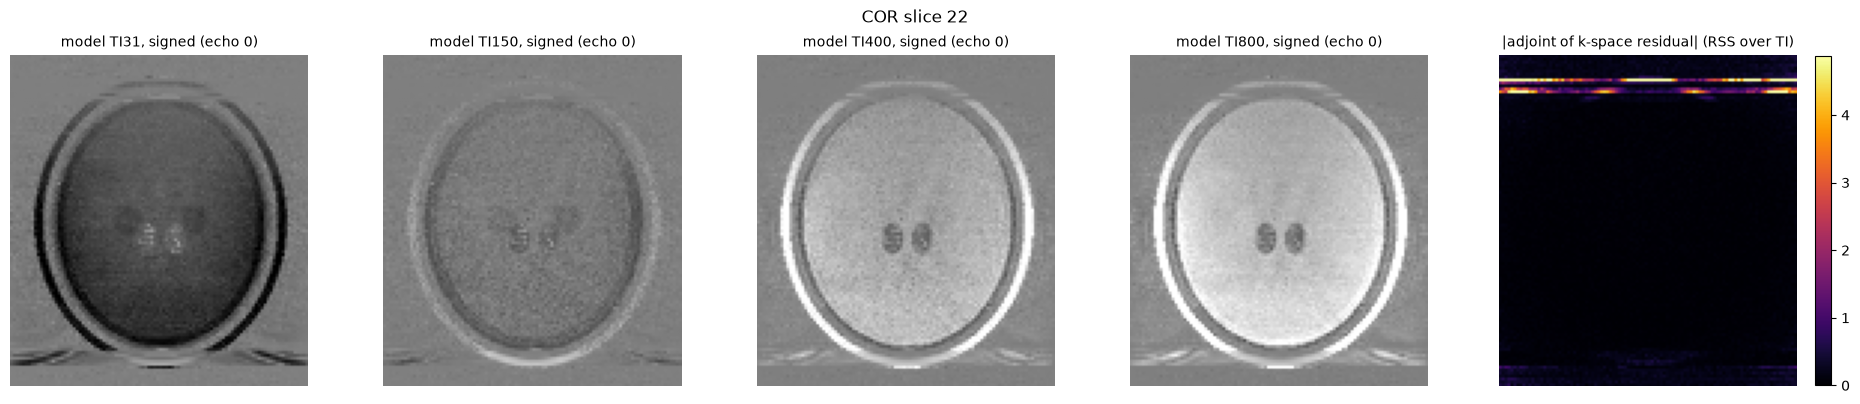

In [23]:
e = 0
m = rec[PLANE, e]['maps']
S = model_images(m, TI)
rss = np.sqrt(np.sum(np.abs(rec[PLANE, e]['sens']) ** 2, axis=3))
signed = np.real(S * (rss * rec[PLANE, e]['rel_scale'][:, None, None])[..., None]
                 * np.exp(-1j * np.angle(m[..., 0]))[..., None])
vmax = np.percentile(np.abs(signed[..., -1])[head], 99)
fig, axes = plt.subplots(1, 5, figsize=(19, 4))
for j in range(4):
    axes[j].imshow(signed[:, :, z0, j], cmap='gray', vmin=-vmax, vmax=vmax, aspect=ASP)
    axes[j].set_title(f'model TI{1000 * TI[j]:.0f}, signed (echo {e})', fontsize=10); axes[j].axis('off')
rimg = res[e][1]
im = axes[4].imshow(rimg[:, :, z0], cmap='inferno', aspect=ASP, vmin=0, vmax=np.percentile(rimg, 99.5))
axes[4].set_title('|adjoint of k-space residual| (RSS over TI)', fontsize=10); axes[4].axis('off')
plt.colorbar(im, ax=axes[4], fraction=0.046)
plt.suptitle(f'{PLANE} slice {z0}'); plt.tight_layout(); plt.show()

## 13. Is the free M0' consistent with the known recovery time?

For this protocol M0'/M_ss should equal 1 − e^(−c R1*) with c = 1.2 s (section 3); moba
does not impose it. The ratio is independent of moba's scale and phase, so it is a free
consistency check of the estimated maps: departures show how much of the curve shape is
absorbed by the extra degree of freedom (noise, or the partial-volume and phase effects).

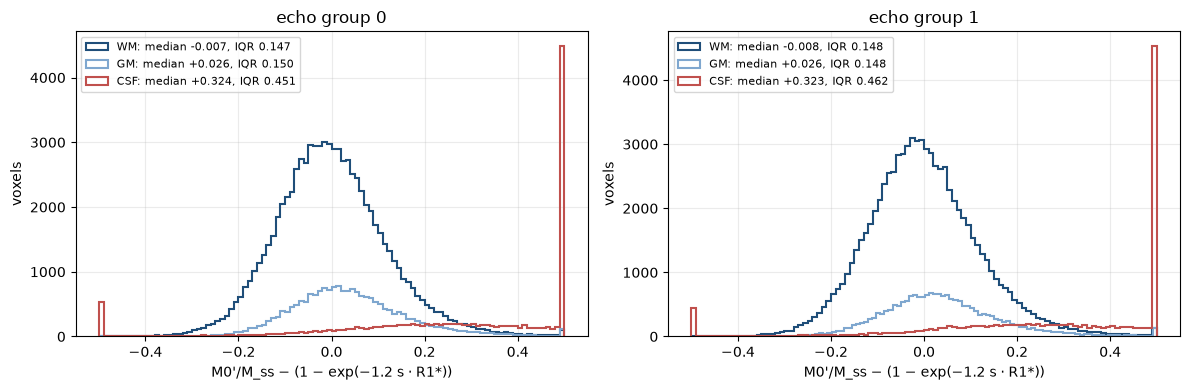

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lab = truth['label']
for e, ax in zip((0, 1), axes):
    m = rec[PLANE, e]['maps']
    ratio = np.real(m[..., 1] / np.where(np.abs(m[..., 0]) > 0, m[..., 0], np.nan))
    pred = 1 - np.exp(-C_NOM * np.real(m[..., 2]))
    for l, name, col in ((5, 'WM', '#1f4e79'), (4, 'GM', '#7fa7cf'), (3, 'CSF', '#c0504d')):
        v = (ratio - pred)[lab == l]
        v = v[np.isfinite(v)]
        ax.hist(np.clip(v, -0.5, 0.5), bins=100, histtype='step', lw=1.5, color=col,
                label=f'{name}: median {np.median(v):+.3f}, IQR {np.subtract(*np.percentile(v, [75, 25])):.3f}')
    ax.set_xlabel("M0'/M_ss − (1 − exp(−1.2 s · R1*))"); ax.set_ylabel('voxels')
    ax.set_title(f'echo group {e}'); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 14. Coil-map QC

moba's coils vs (i) `shared_selfcal(nmaps=1)` — the pipeline's calibration restricted to one
map set, the closest counterpart — and (ii) the true phantom maps (oracle). All maps are
normalised to unit RSS over coils (moba's own RSS carries part of the image intensity), and
compared by the correlation of |map| per coil inside the head; the relative phase between
map sets is irrelevant to T1 (it lands in the complex M_ss/M0').

|map| correlation per coil, echo 0, inside the head
  moba vs shared_selfcal(nmaps=1): [0.955 0.942 0.952 0.971 0.937 0.955 0.933 0.962]


  moba vs true maps              : [0.961 0.983 0.973 0.981 0.975 0.966 0.965 0.986]
  selfcal(1) vs true maps        : [0.959 0.936 0.943 0.959 0.93  0.947 0.942 0.968]


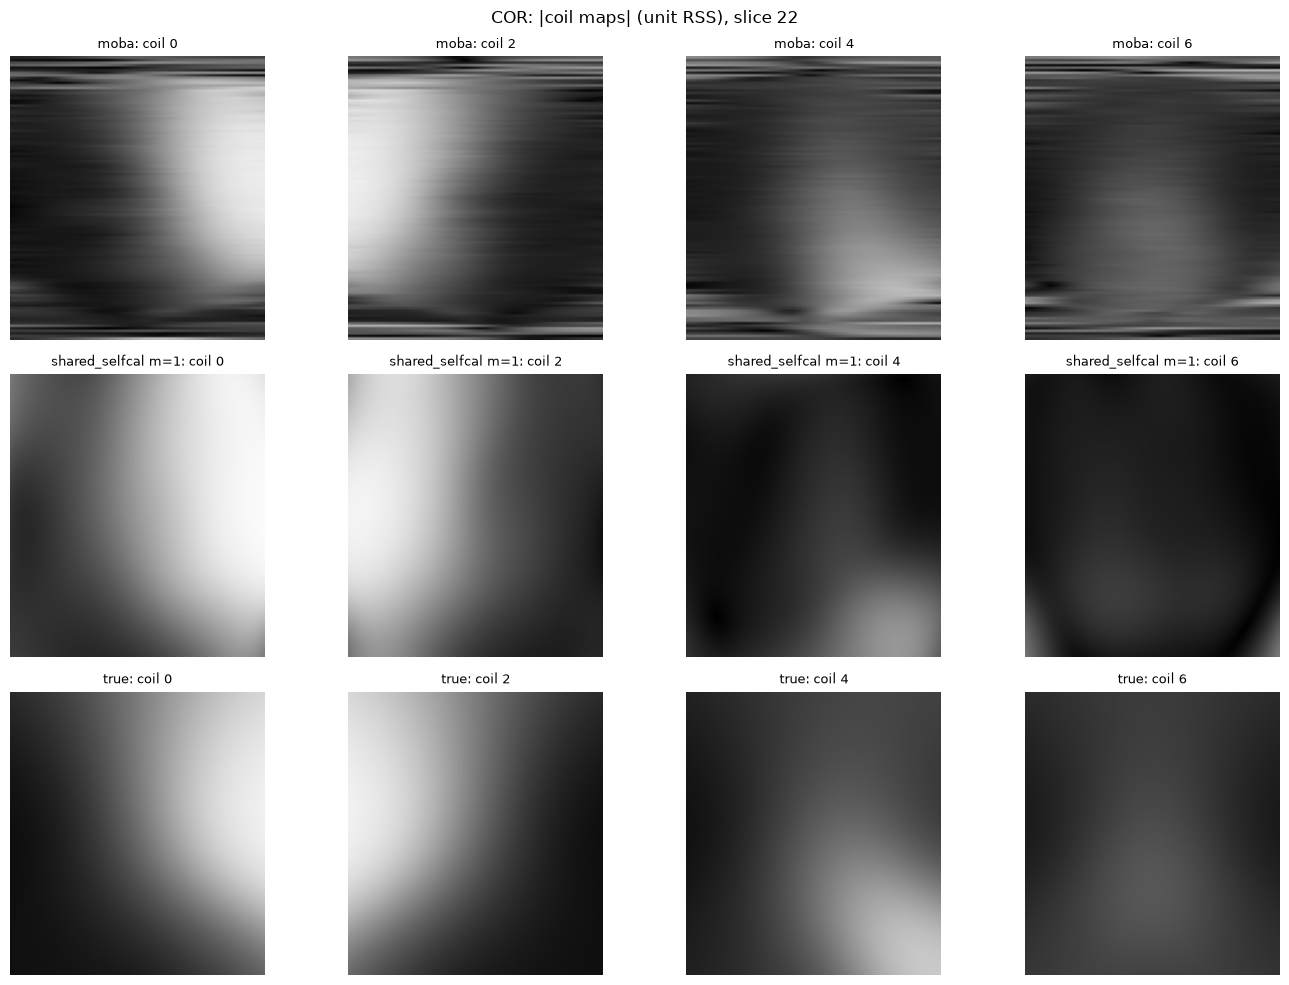

In [25]:
def coil_agreement(a, b, mask):
    a = pu.unit_rss(a)[..., 0]; b = pu.unit_rss(b)[..., 0]
    return np.array([np.corrcoef(np.abs(a[..., c])[mask], np.abs(b[..., c])[mask])[0, 1]
                     for c in range(a.shape[3])])


f = PROC_DIR / f'sens_selfcal_m1_{PLANE}_e0.npy'
if f.exists():
    sc1 = np.load(f)
else:
    sc1 = pu.shared_selfcal(scans[PLANE], 0, nmaps=1)[..., 0]
    np.save(f, sc1)
ms = rec[PLANE, 0]['sens']
print('|map| correlation per coil, echo 0, inside the head')
print('  moba vs shared_selfcal(nmaps=1):', np.round(coil_agreement(ms, sc1, head), 3))
print('  moba vs true maps              :', np.round(coil_agreement(ms, truth['sens'], head), 3))
print('  selfcal(1) vs true maps        :', np.round(coil_agreement(sc1, truth['sens'], head), 3))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for r_, (nm, s) in enumerate((('moba', ms), ('shared_selfcal m=1', sc1), ('true', truth['sens']))):
    u = pu.unit_rss(s)[..., 0]
    for c_ in range(4):
        axes[r_, c_].imshow(np.abs(u[:, :, z0, 2 * c_]), cmap='gray', vmin=0, vmax=1, aspect=ASP)
        axes[r_, c_].set_title(f'{nm}: coil {2 * c_}', fontsize=9); axes[r_, c_].axis('off')
plt.suptitle(f'{PLANE}: |coil maps| (unit RSS), slice {z0}'); plt.tight_layout(); plt.show()

## 15. LLR reference (context only, no tuning of either)

`python synth/run_llr_reference.py <PHANTOM_DIR> COR` writes `llr_COR.npz` (shared-TI
self-calibrated maps, 2 map sets, `pics -e -S -N -R L:7:7:0.006 -i 80 -b 4 -U`, both echo
groups, PSIR, grid fit). Loaded here if present and evaluated with the same function.

region                true   ideal     LLR    moba   LLR vs ideal% moba vs ideal%
WM                   259.8   259.8   258.6   259.2            -0.4           -0.2
GM                   309.2   308.8   307.1   301.5            -0.5           -2.3
CSF                 3543.3  3862.6   190.4 84275.1           -95.1         2079.3
lesion 1 (10 mm)     338.0   313.7   293.4   306.4            -6.5           -2.3
lesion 2 (6 mm)      338.0   304.2   278.5   291.2            -8.5           -4.3
lesion 3 (4 mm)      338.0   293.1   275.6   301.2            -5.9            2.8
lesion 4 (2 mm)      338.0   268.3   289.1   281.4             7.7            4.9
lesion 5 (10 mm)     182.0   203.9   230.2   209.9            12.9            2.9
lesion 6 (6 mm)      182.0   211.5   231.3   224.0             9.4            5.9
lesion 7 (4 mm)      182.0   225.1   259.8   236.2            15.4            4.9
lesion 8 (2 mm)      182.0   238.9   243.6   265.5             2.0           11.1


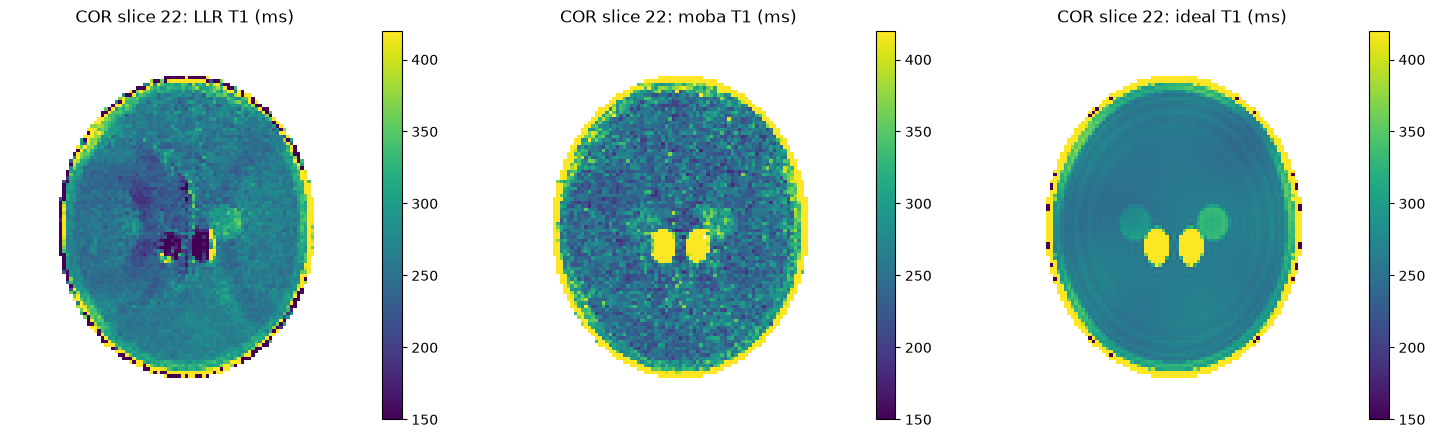

In [26]:
f = PHANTOM_DIR / f'llr_{PLANE}.npz'
if f.exists():
    llr = dict(np.load(f))
    rows_llr = pu.evaluate_t1(llr['T1_s'], truth)
    print(f"{'region':18s} {'true':>7s} {'ideal':>7s} {'LLR':>7s} {'moba':>7s}   {'LLR vs ideal%':>13s} {'moba vs ideal%':>14s}")
    for a, b in zip(rows_llr, rows):
        print(f"{a['region']:18s} {a['true_ms']:7.1f} {a['ideal_ms']:7.1f} {a['est_ms']:7.1f} {b['est_ms']:7.1f}"
              f"   {a['bias_vs_ideal_pct']:13.1f} {b['bias_vs_ideal_pct']:14.1f}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    for ax, v, ttl in ((axes[0], 1000 * llr['T1_s'][:, :, z0], 'LLR T1 (ms)'),
                       (axes[1], 1000 * T1_moba[:, :, z0], 'moba T1 (ms)'),
                       (axes[2], T1_ideal[:, :, z0], 'ideal T1 (ms)')):
        im = ax.imshow(np.where(head[:, :, z0], v, np.nan), cmap='viridis', vmin=150, vmax=420, aspect=ASP)
        ax.set_title(f'{PLANE} slice {z0}: {ttl}'); ax.axis('off'); plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()
else:
    print(f'{f} not found: run synth/run_llr_reference.py first (table in RECON_COMPARISON.md)')

## 16. All three planes

Same code and options for axial and sagittal (`RUN_ALL_PLANES`, set by the environment variable `MOBA_ALL_PLANES=1`). Axial has the zero-padded
TI31 (section 4).

In [27]:
T1_plane = {PLANE: T1_moba}
if RUN_ALL_PLANES:
    for p in PLANES:
        if p == PLANE:
            continue
        for e in (0, 1):
            rec[p, e], state = moba_recon(scans[p], e, p)
            q = rec[p, e]['final_res'] / rec[p, e]['noise_floor']
            print(f"{p} echo {e}: {state}, moba runtime {float(rec[p, e]['runtime_s']) / 60:.1f} min, "
                  f"residual/noise median {np.median(q):.2f}, max {q.max():.2f}, diverged {int((q > 1.5).sum())}")
        tr_p = dict(np.load(PHANTOM_DIR / f'truth_{p}.npz'))
        T1_plane[p] = t1_from([rec[p, e]['maps'] for e in (0, 1)], tr_p['label'] >= 3)
        pu.print_eval(pu.evaluate_t1(T1_plane[p], tr_p), f'\n{p}: moba -L, echo groups combined')
else:
    print('RUN_ALL_PLANES = False -- skipped')

RUN_ALL_PLANES = False -- skipped


In [28]:
if len(T1_plane) > 1:
    fig, axes = plt.subplots(1, len(T1_plane), figsize=(5 * len(T1_plane), 4.4))
    for ax, (p, v) in zip(np.atleast_1d(axes), T1_plane.items()):
        inf = scans[p][pu.REF_TI_IDX]['info']; s_ = pu.spacing_of(inf)
        im = ax.imshow(1000 * v[:, :, v.shape[2] // 2], cmap='viridis', vmin=150, vmax=420, aspect=s_[0] / s_[1])
        ax.set_title(f'{p}: moba T1 (ms), mid pe2 slice'); ax.axis('off'); plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

## 17. What a per-plane T1 output means for the 3-plane super-resolution step

The planned pipeline (`T1map_3plane_SR_V1.ipynb`, steps 4-5; Deoni et al. 2022) combines
**per-TI images** of the three planes in isotropic space and fits T1 there. moba returns
**parameter maps per plane**, not TI images. Consequences and options:

1. **SR of parameter maps.** Super-resolve T1 (or R1*) directly from the three anisotropic
   T1 maps. The SR forward model (slice profile averaging) is linear in the *signal*, not in
   T1: partial volume across a 5 mm slice mixes signals, and T1 of a mixed signal is not the
   average T1. For small lesions (all ≤ 5 mm in at least one direction) this is exactly the
   regime that matters, so parameter-domain SR would be a biased approximation. R1* mixes
   more linearly than T1 but is still not exact.
2. **SR of model-generated TI images (recommended starting point).** Synthesise signed TI
   images per plane from (M_ss, M0', R1*) (section 12), then run the existing per-TI SR and
   isotropic fit unchanged. Caveats: the images are constrained to the model voxel by
   voxel, so partial-volume voxels are forced onto a mono-exponential curve *before* SR;
   M_ss/M0' carry each run's arbitrary scale and phase, so the planes must be intensity-
   normalised (the coil-RSS scaling used here) and phase-referenced per plane before
   combination; and the synthetic images inherit moba's spatial regularisation.
3. **Registration.** Inter-plane registration needs images: use |M_ss| (proton-density-like)
   or a synthetic TI800 image, not T1 (low contrast between WM and GM at 64 mT).
4. **Joint model-based SR (future).** The principled version is one `moba`-like problem for
   all three planes on the isotropic grid (per-plane slice-profile/resampling operator in
   the forward model, one set of parameter maps). Not available in BART as a tool; it would
   need a custom forward operator.
5. **Per-plane T1 as a reference** (as the SR notebook already plans): moba's per-plane maps
   are a direct voxel-wise check of the isotropic result.

## 18. Report (V2: first stable version)

**State.** Every section of this notebook was executed on the static phantom, coronal plane,
both echo groups (sections 1-15; section 16, axial and sagittal, is switched off and was not
run). All numbers below are from the outputs above. Phantom only; no subject data.

### What was wrong in V1, and what V2 changes (section 7)

Measured with the raw-data residual after the last Newton step (moba's own log shows the
residual *entering* each step, which hid it), V1 was broken in 10 of 13 screened readout slices,
central ones included (residual 3-90× the noise floor, 4-19 % of brain voxels with R1* at 0).
Three causes, each shown on single readout slices:

1. **Null space at the R1* bound + no step control.** At R1* = 0, ∂S/∂M_ss = 0, so M_ss is held
   only by the weak late-step wavelet penalty; IRGNM-FISTA has no proximal term on the maps, so
   late steps (α → 0.01, 100 FISTA iterations) can jump. → needs enough α_min.
2. **Per-slice data normalisation** (`--normalize_scaling`) set every slice's data norm to 5000,
   so noisy peripheral slices got ~2.5× less regularisation relative to their noise. → V2 uses a
   **fixed, noise-referenced scale per plane**: `--scale_data 4.545/σ` (σ = k-space noise SD;
   45.0 in the coronal plane) and `--scale_psf` = moba's own PSF normalisation (1000/‖PSF‖).
3. **The default coil model is too smooth.** With `sobolev_a = 880` moba cannot represent the
   coils (10-13 % error for the true coils; the rest goes into the maps: WM at the top of the head
   194 vs 262 ms, image intensity halved there). Per-TI SENSE with the true coils gets those slices
   right. → **`--sobolev_a 220`** (4-6 % representation error).

V2: `moba -L -l1 -i 10 -C 100 -j 0.3 --sobolev_a 220 --scale_data 4.545/σ --scale_psf 1000/‖PSF‖`,
slice-wise along the readout (as V1), default initialisation, echo groups combined as
T1 = 1/mean(R1*). α_min = 0.3 is conservative: 0.1 diverges in 6 of 26 screened slice runs.
Levers that did **not** help: lower bound `-B`, l2 on M_ss, `-N`, initial R1* = 3 s⁻¹ (helps the
top of the head but biases the long-T1 lesion and does not survive more iterations),
`--pusteps/--ratio`, `-C 200` (destabilises a borderline slice). `--other pscale` is not a valid
lever for `-L` in BART v1.0.00 (the model ignores it; only the output is rescaled). Oracle coil
initialisation via `ksp-sens` (conversion implemented and verified) helped much less than the
coil-model change.

### Validation: coronal plane, echo groups combined (section 11)

**Convergence:** 0 of 224 slice runs flagged (raw residual > 1.5× noise floor); median 0.88×
noise floor. Only the scalp-level slices x = 7-15 (and x = 106, echo 1) sit at 1.0-1.27×: part of
the scalp/fat signal at the bottom of the head is not fitted (visible as the band in the residual
image, section 12); no brain in those slices. Global scale check a = 1.0075 (should be 1):
the scaling bookkeeping is right. Echo 1 vs echo 0 T1: median +0.2 %, IQR ±15 % (V1: ±38 %).

Evaluation (`pu.evaluate_t1`; means over the eroded tissue masks and the lesion masks). **LLR**
is the reference method re-run here on the same phantom (`synth/run_llr_reference.py`, unchanged
`LLR_CMD`); it reproduces the table in `RECON_COMPARISON.md` to 0.1 ms, i.e. the regenerated
phantom is identical.

| region | n | ideal (ms) | LLR (ms) | moba V2 (ms) | LLR vs ideal | **moba V2 vs ideal** | ± SE of moba mean* |
|---|---|---|---|---|---|---|---|
| WM | 70965 | 259.8 | 258.6 (SD 20) | 259.2 (SD 31) | −0.4 % | **−0.2 %** | < 0.1 % |
| GM | 3750 | 308.8 | 307.1 (SD 31) | 301.5 (SD 38) | −0.5 % | **−2.3 %** | 0.2 % |
| CSF | 387 | 3867 | 190 | fails (median 1.8 s) | −95 % (PSIR polarity) | fails (ill-conditioned) | – |
| lesion 1, 10 mm, long T1 | 34 | 313.7 | 293.4 (SD 31) | 306.4 (SD 42) | −6.5 % | **−2.3 %** | 2.3 % |
| lesion 2, 6 mm, long | 10 | 304.2 | 278.5 (SD 5) | 291.2 (SD 35) | −8.5 % | **−4.3 %** | 3.6 % |
| lesion 3, 4 mm, long | 4 | 293.1 | 275.6 (SD 3) | 301.2 (SD 17) | −5.9 % | **+2.8 %** | 2.8 % |
| lesion 4, 2 mm, long | 1 | 268.3 | 289.1 | 281.4 | +7.7 % | **+4.9 %** | 1 voxel |
| lesion 5, 10 mm, short T1 | 34 | 203.9 | 230.2 (SD 15) | 209.9 (SD 28) | +12.9 % | **+2.9 %** | 2.4 % |
| lesion 6, 6 mm, short | 7 | 211.5 | 231.3 (SD 8) | 224.0 (SD 20) | +9.4 % | **+5.9 %** | 3.6 % |
| lesion 7, 4 mm, short | 4 | 225.1 | 259.8 (SD 5) | 236.2 (SD 26) | +15.4 % | **+4.9 %** | 5.8 % |
| lesion 8, 2 mm, short | 1 | 238.9 | 243.6 | 265.5 | +2.0 % | **+11.1 %** | 1 voxel |

\* SD/√n relative to ideal, assuming independent voxels — a lower bound, since the regulariser
correlates neighbouring voxels. 1-voxel lesions are single noisy samples for both methods.

**Reading.** In WM, V2 matches the ideal as well as LLR; GM is 2.3 % low (LLR −0.5 %). For the
lesions, V2's bias vs ideal is smaller than LLR's for the 10, 6 and 4 mm lesions of both
polarities (e.g. 10 mm: −2.3 vs −6.5 % and +2.9 vs +12.9 %): LLR pulls lesions towards WM,
V2 much less. But V2 is **noisier** (voxel SD ~1.5× LLR's in WM, lesion SDs 1.4-7× LLR's), so for
the 6 and 4 mm lesions the differences amount to only 1-3 standard errors (a lower bound, see *),
and the 2 mm lesions are single noisy voxels. The fair comparison is at matched noise (or matched
resolution) — part of the tuning (stages 2 and 5). Qualitatively (section 15 figure): LLR is
smoother but its errors are *structured* (a low-T1 streak region around the left deep GM;
ventricles inverted by the PSIR polarity), whereas V2's error is unstructured, voxel-scale
noise, with the ventricles correctly long-T1 and the deep-GM nuclei faintly visible.

WM and GM **medians** (eroded masks): WM 256.1 ms vs ideal 259.6 (−1.3 %), IQR 237-277,
robust SD 29 ms; GM 298.9 vs 308.0 (−3.0 %), robust SD 37 ms. No voxel of the eroded WM and GM
masks has T1 > 1 s (V1: 3.8 % of WM, 14 % of GM).

### Other checks

* **Model consistency (section 13):** M0'/M_ss − (1 − e^(−1.2 s·R1*)) has median −0.01 (WM) and
  +0.03 (GM), IQR 0.15: the free M0' agrees with the known recovery time in tissue; not in CSF
  (+0.32), see limitations.
* **Coils (section 14):** moba's coils correlate 0.96-0.99 with the true maps per coil (|map|
  inside the head), better than `shared_selfcal(nmaps=1)` (0.93-0.97).
* **Data consistency per TI (section 12):** residual at or below the noise floor at every TI.

### Known limitations

* **CSF fails.** Median T1 1.8 s vs ideal 5.0 s (eroded CSF mask; the mean is meaningless, a few
  voxels have R1* ≈ 0). With TIs ≤ 0.8 s a CSF curve is still almost linear, the 3-parameter model
  is ill-conditioned there (section 3: +11 % from the TI31 recovery-time mismatch alone), and the
  joint wavelet likely pulls the thin CSF layers towards the surrounding tissue (not tested). (LLR's CSF failure has a different
  cause, the PSIR polarity.) CSF is not a target of this protocol; flagged, not fixed.
* **Noise.** WM robust SD 29 ms (11 %) with α_min = 0.3 — the price of stability and of fitting
  3 parameters where the PSIR fit uses 2. Regularisation strength is tuning stage 2.
* **GM −3 %** and a small WM deficit in the central pe2 slices (median −7 to −11 ms at z = 21-23):
  most likely regularisation towards the surroundings (not isolated yet); revisit with the regulariser.
* **Slice-wise 2D:** no regularisation along the readout; each readout slice is its own problem
  (visible as horizontal streaks in the background, not in tissue). 3D is not retried yet.
* **One noise realisation, static phantom only**; the stability margin (α_min 0.1 → 0.3) is from
  13 screened slices and the full plane of this realisation.
* The per-TI phase estimate carries a systematic ~1° error at TI150 (section 5); not revisited.

### Runtime (4-core container, 4 slices in parallel, 1 thread each)

moba V2: 18.6 min (echo 0) + 16.2 min (echo 1) for the coronal plane (~0.6 core-min per slice);
the whole notebook incl. the cached section-7 diagnosis ~40 min. LLR reference: 35 min (both echo groups, incl. two `ncalib` runs; `pics` 14.5 min per echo group).
Section 7 from scratch: ~25 min (all runs are cached in `PROC_DIR/diag/cache`).

### Tuning plan (proposal — each stage runs only after the researcher's go-ahead)

Order as suggested: stability → regularisation strength and type → iteration counts → coil
initialisation → image-quality sweeps. Costs on this 4-core container (one readout slice with
`-i 10 -C 100` ≈ 48 s single-threaded, 4 in parallel):

| unit | what | per configuration |
|---|---|---|
| **screen** | 13 readout slices (x = 8…104) × 2 echo groups: stability over the whole head | ≈ 5.5 min |
| **lesion slab** | the 18 readout slices through all 8 lesions (x = 62-79) × 2 echo groups: per-lesion bias vs ideal, WM/GM in the slab, figures | ≈ 7.5 min |
| **full plane** | 112 slices × 2 echo groups (section 8) | ≈ 35 min (measured) |

Every stage reports bias vs ideal (the key number) per tissue and per lesion, SD, the
per-slice residual/noise-floor QC, and runtime; grid figures as in
`T1map_3plane_SR_V1.ipynb` §13 (rows = the swept strength, columns = the second parameter):
T1 map through the lesion plane, a lesion zoom, the model-generated signed TI800 and TI150
images, and the error vs ideal, all with shared windows.

**Stage 1 — stability boundary (α_min).** *Tests:* the smallest α_min at which every slice
converges, i.e. how much regularisation stability forces on us (V2's 0.3 is conservative:
0.1 diverges in 6/26 slice runs). *Grid:* `-j` ∈ {0.15, 0.2, 0.25} on the screen; `-R 3` at the
lowest stable value; and an **adaptive fallback** (run at the lower α_min, re-run only the
slices flagged by the residual QC at 0.3). *Runtime:* ≈ 25 min (screens) + 35 min
(full-plane confirmation of the choice). *Decision:* smallest α_min with 0 flagged slice runs,
plus one grid step of margin — or the adaptive fallback if the boundary is slice-specific
and the lower α_min clearly reduces lesion bias. *Caveat:* one noise realisation; optionally
confirm the boundary on a second phantom seed (`--seed 1`, 12 min to generate).

**Stage 2 — regularisation strength and type (at the stage-1 α_min).**
*2a strength, decoupled from stability:* `--l1val` scales only the wavelet threshold
(α_min also weights the coil penalty); grid {0.25, 0.5, 1, 2} → screen (stability) + lesion
slab, ≈ 1 h. *2b type:* joint l1-wavelet (current) vs total variation on the maps via ADMM
(`-r T:6:0:λ`, 3 values of λ; moba's `-r` path is experimental) vs wavelet on M_ss/M0' only
(`--not-wav-maps 1`, R1* unregularised — expected unstable, screen only), ≈ 1 h.
*Decision:* lowest lesion bias vs ideal at WM/GM bias within ±2 % and no flagged slices,
with the researcher's visual judgement from the grid figures.

**Stage 3 — iteration counts.** `-i` ∈ {8, 10, 12, 14} × `-C` ∈ {50, 100} on the lesion slab
(≈ 70 min; a subset if stages 1-2 make some cells moot) + convergence curve (relative change
vs the longest run, as in the LLR sweep). *Decision:* the cheapest setting whose lesion T1 is
within 1 % of the longest run and whose screen stays stable (more FISTA iterations
destabilised a borderline slice with the old coil model, section 7f).

**Stage 4 — coil model and initialisation.** `--sobolev_a` ∈ {110, 220, 440}, and
`ksp-sens` initialisation from `shared_selfcal(nmaps=1)` (converted by
`diag_slice.ksp_from_coils`) vs moba's default zero coils; screen + slab, ≈ 75 min.
*Decision:* the smoothest coil model that keeps WM/lesion bias at the `a = 220` level;
selfcal initialisation only if it helps on the phantom (on real data it also matters for the
coronal band artefact of single-map ENLIVE, which the phantom cannot show).

**Stage 5 — image-quality sweep for visual assessment.** A 3 × 3 grid around the chosen
point (rows: α_min or `l1val`; columns: Newton steps) on the lesion slab (≈ 80 min), figures
and phantom table per cell. Then the final full-plane run (35 min) and AX/SAG (≈ 90 min).

**Open design items (not tuning; later, on request):** 3D `moba` instead of slice-wise (the
fixed, noise-referenced scaling removes V1's reason for its failure; one 3D run ≈ 1-2 h
here and needs its own α calibration); re-estimating the per-TI phase from the model
(section 5, alternative 2); echo-group combination (joint vs mean R1*).